In [ ]:
import importlib
import sys
from pathlib import Path

# Add mjosa_code root to path
mjosa_code_root = Path.cwd().parent  # Up to mjosa_code root
sys.path.insert(0, str(mjosa_code_root))

# Import from mjosa_code (NEW structure)
from utils.uhi import georef
from utils.common import config

importlib.reload(georef)  # RELOAD to get updated function!
from utils.uhi.georef import *

print(f"✅ Imports successful! mjosa_code root: {mjosa_code_root}")
print(f"✅ NEW FEATURES LOADED:")
print(f"   - Gaussian smoothing (smoothing_method='gaussian', gaussian_sigma=value)")
print(f"   - L2 normalization (normalization_method='l2')")

## Load UHI Data

In [ ]:
# Load transect 057
transect = load_transect(config.TRANSECT_057_OUTPUT)
transect.list_files()

# Select file from transect 057
cube = transect.select_files(["rad_uhi_20241029_115057_5"])
cube.describe()

In [ ]:
# Step 1: Apply illumination correction
cube.apply_illumination_correction_v3()

In [ ]:
cube.adjust_uhi_alignment(dx=-0.05, dy=-3.0)

In [ ]:
cube.apply_wavelength_filter(wavelength_range=(490, 700))

In [ ]:
# Define analysis lines - ADJUSTED for track range (576-1566)
# Place lines within visible data range
line1 = [(410, 710), (940, 780)]
line2 = [(340, 1030), (340, 1210)]
line3 = [(250, 890), (250, 990)]
line4 = [(300, 1358), (300, 1458)]

lines = [line1, line2, line3, line4]
colors = ["red", "blue", "orange", "magenta"]
labels = ["Line 1", "Line 2", "Line 3", "Line 4"]

# Plot RGB georef - EXACT wavelengths: 677nm (R), 610nm (G), 490nm (B)
# plot_georef will find the CLOSEST available wavelength to these targets
from unittest.mock import patch
import matplotlib.pyplot as plt

# Monkeypatch to prevent show() so we can customize legend
with patch.object(plt, "show", lambda: None):
    cube.plot_georef(
        perimeter_line=lines,
        line_colors=colors,
        line_width=3,
        line_labels=labels,
        use_corrected=True,
        coordinate_system="NED",
        track_start=config.UHI_TRACK_RANGE[0],
        track_end=config.UHI_TRACK_RANGE[1],
        figsize=(50, 20),
        apply_alignment_shift=True,
    )

# Customize legend: no border, fully white background (not translucent)
ax = plt.gca()
if ax.get_legend():
    ax.get_legend().remove()
handles, labels_leg = ax.get_legend_handles_labels()
if handles:
    legend = ax.legend(
        handles,
        labels_leg,
        loc="best",
        frameon=False,  # No border
        framealpha=1,
        facecolor="white",
    )
    legend.get_frame().set_alpha(1)
    for lh in legend.legend_handles:
        lh.set_alpha(1)

plt.tight_layout()
plt.show()

# MONKEYPATCH: Prevent plt.show() from displaying until we customize legend
with patch.object(plt, "show", lambda: None):
    cube.plot_line_intensity_profile(
        perimeter_line=lines,
        use_average=True,
        moving_average_percent=6,
        show_markers=False,
        line_labels=labels,
        line_colors=colors,
        use_corrected=True,
        wavelength_range="all",
        figsize=(10, 10),
        use_sparse_sampling=True,
    )

# Customize plot: remove grid, move legend to lower right, trim x-axis
ax = plt.gca()
ax.grid(False)

# Remove old legend and create new one in lower right (no border)
if ax.get_legend():
    ax.get_legend().remove()
handles, labels_leg = ax.get_legend_handles_labels()
legend = ax.legend(
    handles,
    labels_leg,
    loc="lower right",
    fontsize=10,
    frameon=False,
    framealpha=1,
    facecolor="white",
)
legend.get_frame().set_alpha(1)
for lh in legend.legend_handles:
    lh.set_alpha(1)

# Trim x-axis to remove ALL whitespace by using actual data range
all_lines = ax.get_lines()
if all_lines:
    min_x = min([min(line.get_xdata()) for line in all_lines])
    max_x = max([max(line.get_xdata()) for line in all_lines])
    ax.set_xlim(min_x, max_x)

plt.tight_layout()
plt.show()

In [ ]:
# Wavelength comparison with EXACT wavelengths and ACTUAL PHYSICAL COLORS
# Using the plot_wavelength_comparison function with single wavelength integers
# Loop through all 4 lines with consistent formatting
for i, line in enumerate(lines):
    print(f"\n[{i+1}/{len(lines)}] {labels[i]}:")

    # MONKEYPATCH: Prevent plt.show() from displaying until we customize
    with patch.object(plt, "show", lambda: None):
        cube.plot_wavelength_comparison(
            line=line,
            wavelength_ranges=[
                677,  # Deep red (finds closest: 677.6nm) -> physical red color
                610,  # Orange (finds closest: 609.5nm) -> physical orange color
                490,  # Cyan (finds closest: 490.2nm) -> physical cyan color
            ],
            moving_average_percent=6,
            use_corrected=True,
            figsize=(10, 10),
        )

    # Remove legend completely and grid, then trim x-axis
    ax = plt.gca()
    ax.grid(False)
    ax.set_axisbelow(False)
    if ax.get_legend():
        ax.get_legend().remove()

    # Trim x-axis to remove ALL whitespace by using actual data range
    all_lines = ax.get_lines()
    if all_lines:
        min_x = min([min(line.get_xdata()) for line in all_lines])
        max_x = max([max(line.get_xdata()) for line in all_lines])
        ax.set_xlim(min_x, max_x)

    plt.tight_layout()
    plt.show()

print(f"\n✅ All wavelength comparison plots complete!")

In [ ]:
stop

# 📄 Export Transect 057 PDFs

Save all transect 057 plots as high-quality PDFs for Adobe Illustrator editing.


In [ ]:
# Create output folder structure for transect 057
from pathlib import Path

output_dir_057 = (
    Path.cwd().parent / "images_for_publication" / "intensity_profiles" / "transect_057"
)
output_dir_057.mkdir(parents=True, exist_ok=True)

print(f"✅ Output folder created: {output_dir_057}")

In [ ]:
# Save RGB georef plot as PDF
import matplotlib.pyplot as plt
from unittest.mock import patch

print("=" * 80)
print("SAVING RGB GEOREF AS PDF")
print("=" * 80)

# Monkeypatch to prevent show() so we can customize legend
with patch.object(plt, "show", lambda: None):
    cube.plot_georef(
        perimeter_line=lines,
        line_colors=colors,
        line_width=3,
        line_labels=labels,
        use_corrected=True,
        coordinate_system="NED",
        track_start=config.UHI_TRACK_RANGE[0],
        track_end=config.UHI_TRACK_RANGE[1],
        figsize=(50, 20),
        apply_alignment_shift=True,
    )

# Customize legend: no border, fully white background (not translucent)
ax = plt.gca()
if ax.get_legend():
    ax.get_legend().remove()
handles, labels_leg = ax.get_legend_handles_labels()
if handles:
    legend = ax.legend(
        handles,
        labels_leg,
        loc="best",
        frameon=False,  # No border
        framealpha=1,
        facecolor="white",
    )
    legend.get_frame().set_alpha(1)
    for lh in legend.legend_handles:
        lh.set_alpha(1)
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("")
ax.set_xticks([])
ax.set_yticks([])
# Remove all spines (borders)
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()

# Save as PDF
filepath = output_dir_057 / "rgb_georef_overview.pdf"
plt.savefig(filepath, format="pdf", bbox_inches="tight", dpi=300)
plt.close()

print(f"✅ Saved: rgb_georef_overview.pdf")

In [ ]:
# Save combined intensity profile as PDF
import matplotlib.pyplot as plt
from unittest.mock import patch

print("=" * 80)
print("SAVING COMBINED INTENSITY PROFILE AS PDF")
print("=" * 80)

# MONKEYPATCH: Prevent plt.show() from displaying until we customize legend
with patch.object(plt, "show", lambda: None):
    cube.plot_line_intensity_profile(
        perimeter_line=lines,
        use_average=True,
        moving_average_percent=6,
        show_markers=False,
        line_labels=labels,
        line_colors=colors,
        use_corrected=True,
        wavelength_range="all",
        figsize=(10, 10),
        use_sparse_sampling=True,
    )

# Customize plot: remove grid, move legend to lower right, trim x-axis
ax = plt.gca()
ax.grid(False)

# Remove old legend and create new one in lower right (no border)
if ax.get_legend():
    ax.get_legend().remove()
handles, labels_leg = ax.get_legend_handles_labels()
legend = ax.legend(
    handles,
    labels_leg,
    loc="lower right",
    fontsize=10,
    frameon=False,
    framealpha=1,
    facecolor="white",
)
legend.get_frame().set_alpha(1)
for lh in legend.legend_handles:
    lh.set_alpha(1)

# Trim x-axis to remove ALL whitespace by using actual data range
all_lines = ax.get_lines()
if all_lines:
    min_x = min([min(line.get_xdata()) for line in all_lines])
    max_x = max([max(line.get_xdata()) for line in all_lines])
    ax.set_xlim(min_x, max_x)

# Remove axis labels, ticks, and borders for clean publication figure

plt.tight_layout()

# Save as PDF
filepath = output_dir_057 / "combined_intensity_profiles.pdf"
plt.savefig(filepath, format="pdf", bbox_inches="tight", dpi=300)
plt.close()

print(f"✅ Saved: combined_intensity_profiles.pdf")

In [ ]:
# Save wavelength comparison plots as PDFs
import matplotlib.pyplot as plt
from unittest.mock import patch

print("=" * 80)
print("SAVING WAVELENGTH COMPARISON PLOTS AS PDFs")
print("=" * 80)

wavelengths = [677, 610, 490]

for i, line in enumerate(lines):
    print(f"  [{i+1}/{len(lines)}] {labels[i]}...")

    # MONKEYPATCH: Prevent plt.show() from displaying until we customize
    with patch.object(plt, "show", lambda: None):
        cube.plot_wavelength_comparison(
            line=line,
            wavelength_ranges=wavelengths,
            moving_average_percent=6,
            use_corrected=True,
            figsize=(10, 10),
        )

    # Remove legend completely and grid, then trim x-axis
    ax = plt.gca()
    ax.grid(False)
    ax.set_axisbelow(False)
    if ax.get_legend():
        ax.get_legend().remove()

    # Trim x-axis to remove ALL whitespace by using actual data range
    all_lines = ax.get_lines()
    if all_lines:
        min_x = min([min(line.get_xdata()) for line in all_lines])
        max_x = max([max(line.get_xdata()) for line in all_lines])
        ax.set_xlim(min_x, max_x)

    plt.tight_layout()

    # Save as PDF
    filename = f"wavelength_comparison_line_{i+1}.pdf"
    filepath = output_dir_057 / filename
    plt.savefig(filepath, format="pdf", bbox_inches="tight", dpi=300)
    plt.close()

    print(f"      Saved: {filename}")

print(f"\n✅ Saved {len(lines)} wavelength comparison PDFs!")

---

---

---

---

---

---

---

---

---

---

---

---

---

---

---

---

---

---

---

---

---

---

---

---

---

---

---

---

---

---

---

---

---

---

---

---

---

---

---

---

---

---

---

---

---

---

---

---

---

---
---
---
---
---
---
---
---
---
---
---


In [ ]:
stop

# Transect 028 Crop Lines Analysis

Load transect 028 data (same preprocessing as transect 057) and create intensity profile lines for cropped regions.

In [1]:
import importlib
import sys
from pathlib import Path

# Add mjosa_code root to path
mjosa_code_root = Path.cwd().parent  # Up to mjosa_code root
sys.path.insert(0, str(mjosa_code_root))

# Import from mjosa_code (NEW structure)
from utils.uhi import georef
from utils.common import config

importlib.reload(georef)  # RELOAD to get updated function!
from utils.uhi.georef import *

print(f"✅ Imports successful! mjosa_code root: {mjosa_code_root}")
print(f"✅ NEW FEATURES LOADED:")
print(f"   - Gaussian smoothing (smoothing_method='gaussian', gaussian_sigma=value)")
print(f"   - L2 normalization (normalization_method='l2')")

✅ Imports successful! mjosa_code root: e:\mjosa_complete\gref4hsi\mjosa_code
✅ NEW FEATURES LOADED:
   - Gaussian smoothing (smoothing_method='gaussian', gaussian_sigma=value)
   - L2 normalization (normalization_method='l2')


In [2]:
# Load transect 028 (same preprocessing as transect 057)
transect_028 = load_transect(config.TRANSECT_028_OUTPUT)
transect_028.list_files()

# Select all 5 files from transect 028
cube_028 = transect_028.select_files(
    [
        "rad_uhi_20241029_125028_1",
        "rad_uhi_20241029_125028_2",
        "rad_uhi_20241029_125028_3",
        "rad_uhi_20241029_125028_4",
        "rad_uhi_20241029_125028_5",
    ]
)
cube_028.describe()


📋 Files in output (corrected=False):
 1. rad_uhi_20241029_125028_1  | shape=(1329, 968, 210)  | has_georef=True
 2. rad_uhi_20241029_125028_2  | shape=(2011, 968, 210)  | has_georef=True
 3. rad_uhi_20241029_125028_3  | shape=(2282, 968, 210)  | has_georef=True
 4. rad_uhi_20241029_125028_4  | shape=(2457, 968, 210)  | has_georef=True
 5. rad_uhi_20241029_125028_5  | shape=(1948, 968, 210)  | has_georef=True
🔄 Rebuilding grids from georef hits for selected files...
   • rad_uhi_20241029_125028_1
  rad_uhi_20241029_125028_1: Using GRIDDED format (T=1329, S=968)
   • rad_uhi_20241029_125028_2
  rad_uhi_20241029_125028_2: Using GRIDDED format (T=2011, S=968)
   • rad_uhi_20241029_125028_3
  rad_uhi_20241029_125028_3: Using GRIDDED format (T=2282, S=968)
   • rad_uhi_20241029_125028_4
  rad_uhi_20241029_125028_4: Using GRIDDED format (T=2457, S=968)
   • rad_uhi_20241029_125028_5
  rad_uhi_20241029_125028_5: Using GRIDDED format (T=1948, S=968)
✅ Combined shapes: X/Y/Z (10027, 968), RGB (

In [3]:
# Apply illumination correction v3 (same as transect 057)
cube_028.apply_illumination_correction_v2()

🔄 Using V2 algorithm (pandas rolling median, memory-efficient)
✅ Illumination correction already applied with window=500, strength=1.0
   Loading from disk...
📂 Loading saved illumination correction from 5 files...
   rad_uhi_20241029_125028_1: window=500, strength=1.0
   rad_uhi_20241029_125028_2: window=500, strength=1.0
   rad_uhi_20241029_125028_3: window=500, strength=1.0
   rad_uhi_20241029_125028_4: window=500, strength=1.0
   rad_uhi_20241029_125028_5: window=500, strength=1.0
✅ Loaded illumination correction from disk


array([[[0.00000000e+00, 8.00363868e-02, 3.38807702e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         9.79862548e-03, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 6.24412894e-01, 0.00000000e+00, ...,
         2.43312144e+00, 0.00000000e+00, 0.00000000e+00],
        ...,
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         4.49576187e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 1.18552887e+00, ...,
         2.34972164e-01, 0.00000000e+00, 0.00000000e+00],
        [9.47257459e-01, 0.00000000e+00, 0.00000000e+00, ...,
         3.01917344e-01, 0.00000000e+00, 0.00000000e+00]],

       [[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         1.15298668e+02, 1.14839525e+01, 3.45664215e-03],
        [0.00000000e+00, 1.00000000e+00, 9.11504328e-01, ...,
         2.32659373e-02, 2.43540382e+00, 4.57144403e+00],
        [0.00000000e+00, 

In [4]:
# Apply wavelength filter (same as transect 057)
cube_028.apply_wavelength_filter(wavelength_range=(490, 700))
# Note: 028 does NOT need alignment adjustment (only 057 needs it)

🔪 WAVELENGTH FILTERING
📊 Original wavelengths: 210
🎯 Target range: 490-700 nm
✂️  Filtered wavelengths: 119
📉 Range: 490.2 - 699.4 nm

✅ Datacube shape after filtering: (10027, 968, 119)
   Memory: 4.30 GB


array([[[1.2759849 , 1.3764842 , 0.9675436 , ..., 0.9496982 ,
         1.0709273 , 1.0304216 ],
        [0.9483693 , 1.1072787 , 1.0143884 , ..., 0.7748344 ,
         1.2144363 , 1.5298256 ],
        [0.96234936, 1.1124578 , 1.089599  , ..., 0.96160984,
         1.2418723 , 1.2589979 ],
        ...,
        [1.1645297 , 1.149324  , 0.7894244 , ..., 0.7789155 ,
         0.9954487 , 1.3138553 ],
        [1.0814096 , 1.0791473 , 0.9575742 , ..., 0.626929  ,
         1.2137746 , 1.412802  ],
        [1.046624  , 1.223626  , 0.9056041 , ..., 0.704242  ,
         1.1944201 , 1.7312926 ]],

       [[0.85755616, 1.2813288 , 1.2058005 , ..., 1.1760564 ,
         1.029976  , 0.816674  ],
        [0.9870923 , 1.2190492 , 0.88129497, ..., 1.0860927 ,
         0.8832713 , 0.9817302 ],
        [0.6773623 , 1.1124578 , 1.        , ..., 1.070382  ,
         1.2418723 , 1.0267929 ],
        ...,
        [0.86383754, 1.0105064 , 1.0795507 , ..., 1.1323885 ,
         1.        , 1.4766228 ],
        [0.8

## Define Crop Regions and Lines (Local Coordinates)

Lines are defined in LOCAL crop coordinates:
- X-axis: 0 to crop_width (default 500 pixels)
- Y-axis: 0 to crop_height (default 125 pixels for aspect_ratio=4)

In [5]:
# Crop regions from notebook 8 (global track/slit coordinates)
crop_regions_028 = [
    {"track": 5160, "slit": 613, "label": "Bomb 1"},
    {"track": 1258, "slit": 250, "label": "Bomb 2"},
    {"track": 5592, "slit": 700, "label": "Bomb 3"},
    {"track": 717, "slit": 385, "label": "Dark pits"},
    # {"track": 4126, "slit": 682, "label": "Between 1-2"},
    # {"track": 4310, "slit": 482, "label": "Between 1-2"},
    {"track": 4200, "slit": 482, "label": "Between 1-2"},
    # {"track": 4326, "slit": 882, "label": "Between 1-2"},
    # {"track": 4426, "slit": 982, "label": "Between 1-2"},
    # {"track": 4526, "slit": 1082, "label": "Between 1-2"},
]

# Lines in LOCAL crop coordinates (crop_width=500, crop_height=125)
# Format: [(x1, y1), (x2, y2)] where x is along width, y is along height
# IMPORTANT: Order is [START, END] so function samples in correct direction!
crop_lines_028 = {
    "Bomb 1": [
        (40, 120),
        (465, 20),
    ],  # Line across bomb center (LEFT to RIGHT, START to END)
    # "Bomb 1": [
    #     (10, 120),
    #     (480, 25),
    # ],  # Alternative line (LEFT to RIGHT, START to END)
    # "Bomb 2": [
    #     (10, 70),
    #     (490, 70),
    # ],  # Line across bomb center (LEFT to RIGHT, START to END)
    "Bomb 2": [
        (120, 120),
        (470, 25),
    ],  # Line across bomb center (LEFT to RIGHT, START to END)
    # "Bomb 2": [
    #     (20, 95),
    #     (470, 55),
    # ],  # Line across bomb center (LEFT to RIGHT, START to END)
    "Bomb 3": [
        (175, 110),
        (175, 20),
    ],  # Line across bomb center (LEFT to RIGHT, START to END)
    # "Bomb 3": [
    #     (50, 65),
    #     (340, 65),
    # ],  # Line across bomb center (LEFT to RIGHT, START to END)
    "Dark pits": [
        (15, 60),
        (435, 60),
    ],  # Line across dark pits (LEFT to RIGHT, START to END)
    # "Dark pits": [
    #     (40, 60),
    #     (460, 60),
    # ],  # Line across dark pits (LEFT to RIGHT, START to END)
    "Between 1-2": [
        (70, 60),
        (470, 60),
    ],  # Line in between region (LEFT to RIGHT, START to END)
}

# Colors for line visualization
line_colors_028 = ["red", "blue", "green", "orange", "magenta"]

print(f"✅ Defined {len(crop_regions_028)} crop regions with lines")
print(f"   Crop dimensions: 500 × 125 pixels (width × height)")
print(f"   Line coordinates: LOCAL (0-500 for x, 0-125 for y)")

✅ Defined 5 crop regions with lines
   Crop dimensions: 500 × 125 pixels (width × height)
   Line coordinates: LOCAL (0-500 for x, 0-125 for y)


In [6]:
# # Crop regions from notebook 8 (global track/slit coordinates)
# crop_regions_028 = [
#     {"track": 5160, "slit": 613, "label": "Bomb 1"},
#     {"track": 1258, "slit": 250, "label": "Bomb 2"},
#     {"track": 5592, "slit": 700, "label": "Bomb 3"},
#     {"track": 717, "slit": 385, "label": "Dark pits"},
#     # {"track": 4126, "slit": 682, "label": "Between 1-2"},
#     {"track": 4000

In [7]:
# , "slit": 582, "label": "Between 1-2"},
#     # {"track": 4326, "slit": 882, "label": "Between 1-2"},
#     # {"track": 4426, "slit": 982, "label": "Between 1-2"},
#     # {"track": 4526, "slit": 1082, "label": "Between 1-2"},
# ]

# # Lines in LOCAL crop coordinates (crop_width=500, crop_height=125)
# # Format: [(x1, y1), (x2, y2)] where x is along width, y is along height
# # IMPORTANT: Order is [START, END] so function samples in correct direction!
# crop_lines_028 = {
#     "Bomb 1": [
#         (40, 120),
#         (465, 20),
#     ],  # Line across bomb center (LEFT to RIGHT, START to END)
#     # "Bomb 1": [
#     #     (10, 120),
#     #     (480, 25),
#     # ],  # Alternative line (LEFT to RIGHT, START to END)
#     # "Bomb 2": [
#     #     (10, 70),
#     #     (490, 70),
#     # ],  # Line across bomb center (LEFT to RIGHT, START to END)
#     "Bomb 2": [
#         (120, 120),
#         (470, 25),
#     ],  # Line across bomb center (LEFT to RIGHT, START to END)
#     # "Bomb 2": [
#     #     (20, 95),
#     #     (470, 55),
#     # ],  # Line across bomb center (LEFT to RIGHT, START to END)
#     "Bomb 3": [
#         (175, 110),
#         (175, 20),
#     ],  # Line across bomb center (LEFT to RIGHT, START to END)
#     # "Bomb 3": [
#     #     (50, 65),
#     #     (340, 65),
#     # ],  # Line across bomb center (LEFT to RIGHT, START to END)
#     "Dark pits": [
#         (15, 60),
#         (435, 60),
#     ],  # Line across dark pits (LEFT to RIGHT, START to END)
#     # "Dark pits": [
#     #     (40, 60),
#     #     (460, 60),
#     # ],  # Line across dark pits (LEFT to RIGHT, START to END)
#     "Between 1-2": [
#         (70, 60),
#         (470, 60),
#     ],  # Line in between region (LEFT to RIGHT, START to END)
# }

# # Colors for line visualization
# line_colors_028 = ["red", "blue", "green", "orange", "magenta"]

# print(f"✅ Defined {len(crop_regions_028)} crop regions with lines")
# print(f"   Crop dimensions: 500 × 125 pixels (width × height)")
# print(f"   Line coordinates: LOCAL (0-500 for x, 0-125 for y)")

## Monkeypatch: Add Line Support to plot_rgb for Crops

Create a wrapper function that adds line overlay capability without modifying the original plot_rgb.

In [8]:
import matplotlib.pyplot as plt
from unittest.mock import patch


def plot_crop_with_line(
    cube,
    crop_region,
    line_local,
    line_color="red",
    line_width=3,
    line_label=None,
    feature_indices=None,
    feature_labels=None,
    feature_marker="s",
    feature_markersize=8,
    crop_width=500,
    crop_aspect_ratio=4,
    display_aspect_ratio=4.0,
    use_corrected=True,
    figsize=(30, 8.32),
    show_file_boundaries=False,
    **kwargs,
):
    """
    Plot a cropped RGB region with a line overlay.

    Since plot_rgb disables perimeter_line when cropping, we:
    1. Call plot_rgb to create the RGB crop
    2. Capture the figure BEFORE it closes
    3. Add the line to the same axes using crop-relative coordinates

    Parameters:
    -----------
    cube : CombinedTransectCube
        Preprocessed hyperspectral cube
    crop_region : dict
        {"track": int, "slit": int, "label": str}
    line_local : list
        Line in LOCAL crop coordinates: [(x1, y1), (x2, y2)]
        When flip_axes=True and flip_horizontal=True:
        - x corresponds to slit (horizontal on screen, 0-crop_width)
        - y corresponds to track (vertical on screen, 0-crop_height)
    feature_indices : list, optional
        List of indices along the line (0-based) to mark specific features
        Example: [50, 100, 150] marks features at positions 50, 100, 150
    feature_labels : list, optional
        Labels for each feature marker (same length as feature_indices)
    feature_marker : str, default "s"
        Marker style for features ("s", "o", "D", etc.)
    feature_markersize : int, default 12
        Size of feature markers
    **kwargs : Additional arguments passed to plot_rgb
    """

    label = crop_region.get("label", "Crop")
    track_center = crop_region["track"]
    slit_center = crop_region["slit"]
    crop_height = crop_width // crop_aspect_ratio

    print(f"📊 Plotting RGB crop with line: {label}")
    print(f"   Crop center: (track={track_center}, slit={slit_center})")
    print(f"   Line (local): {line_local}")
    if feature_indices:
        print(f"   Feature markers at indices: {feature_indices}")

    # Monkeypatch plt.show() to prevent plot_rgb from displaying
    with patch.object(plt, "show", lambda: None):
        # Create the RGB crop plot (show() is now a no-op)
        cube.plot_rgb(
            use_corrected=use_corrected,
            figsize=figsize,
            flip_axes=True,
            flip_horizontal=True,
            crop_center_track=track_center,
            crop_center_slit=slit_center,
            crop_width=crop_width,
            crop_aspect_ratio=crop_aspect_ratio,
            display_aspect_ratio=display_aspect_ratio,
            show_file_boundaries=show_file_boundaries,
            **kwargs,
        )

    # Capture the figure (now it hasn't been shown yet)
    fig = plt.gcf()
    ax = plt.gca()

    # Extract line coordinates
    x1_local, y1_local = line_local[0]
    x2_local, y2_local = line_local[1]

    # Get the extent of the displayed image
    extent = ax.images[0].get_extent() if ax.images else None

    if extent:
        slit_min, slit_max, track_min, track_max = extent

        # Convert local crop coordinates to displayed image coordinates
        x1_display = slit_min + (x1_local / crop_width) * (slit_max - slit_min)
        x2_display = slit_min + (x2_local / crop_width) * (slit_max - slit_min)
        y1_display = track_min + (y1_local / crop_height) * (track_max - track_min)
        y2_display = track_min + (y2_local / crop_height) * (track_max - track_min)

        print(
            f"   Line (display): ({x1_display:.1f}, {y1_display:.1f}) → ({x2_display:.1f}, {y2_display:.1f})"
        )

        # Draw the line on the same axes
        ax.plot(
            [x1_display, x2_display],
            [y1_display, y2_display],
            color=line_color,
            linewidth=line_width,
            label=line_label or f"{label} Line",
            zorder=10,
        )

        # Add start marker
        ax.plot(x1_display, y1_display, "o", color=line_color, markersize=8, zorder=11)

        # Add feature markers if specified
        if feature_indices:
            # Calculate line length in local coordinates
            line_length = np.sqrt(
                (x2_local - x1_local) ** 2 + (y2_local - y1_local) ** 2
            )
            num_points = int(line_length) + 1

            print(
                f"   🔍 Line: ({x1_local:.1f},{y1_local:.1f})→({x2_local:.1f},{y2_local:.1f}), length={line_length:.1f}, num_points={num_points}"
            )

            for idx, feature_idx in enumerate(feature_indices):
                if 0 <= feature_idx < num_points:
                    # Interpolate position along line
                    t = feature_idx / max(num_points - 1, 1)
                    x_feature_local = x1_local + t * (x2_local - x1_local)
                    y_feature_local = y1_local + t * (y2_local - y1_local)

                    print(
                        f"      Marker {idx}: index={feature_idx}, t={t:.4f} → ({x_feature_local:.1f},{y_feature_local:.1f})"
                    )

                    # Convert to display coordinates (SAME as line drawing)
                    x_feature_display = slit_min + (x_feature_local / crop_width) * (
                        slit_max - slit_min
                    )
                    y_feature_display = track_min + (y_feature_local / crop_height) * (
                        track_max - track_min
                    )

                    # Plot feature marker (publication style: black, no border)
                    ax.plot(
                        x_feature_display,
                        y_feature_display,
                        marker=feature_marker,
                        color="black",
                        markersize=feature_markersize,
                        zorder=12,
                    )

                    # Add label if provided (no background box, positioned left)
                    if feature_labels and idx < len(feature_labels):
                        ax.text(
                            x_feature_display - 10,
                            y_feature_display,
                            feature_labels[idx],
                            color="black",
                            fontsize=12,
                            fontweight="bold",
                            ha="right",
                            va="center",
                            zorder=13,
                        )

    # Now display the complete figure with line
    plt.show()

    return fig


print("✅ Function created: plot_crop_with_line()")
print("   Creates RGB crop, then adds line to same figure")
print("   Handles coordinate transformation for flipped/cropped display")
print("   ✅ REVERTED: Markers use SAME coordinate system as line (for RGB display)")

✅ Function created: plot_crop_with_line()
   Creates RGB crop, then adds line to same figure
   Handles coordinate transformation for flipped/cropped display
   ✅ REVERTED: Markers use SAME coordinate system as line (for RGB display)


## Monkeypatch: Extract Line Profiles from Crops

Create a function to extract intensity profiles from cropped regions using local line coordinates.

In [9]:
import numpy as np
from scipy import ndimage


def plot_crop_line_intensity_profile(
    cube,
    crop_region,
    line_local,
    line_label="Line",
    line_color="red",
    crop_width=500,
    crop_aspect_ratio=4,
    use_corrected=True,
    wavelength_range="all",
    use_average=True,
    moving_average_percent=20,
    show_markers=False,
    figsize=(12, 6),
    use_sparse_sampling=True,
):
    """
    Extract and plot intensity profile along a line in a cropped region.

    MONKEYPATCH WRAPPER - Converts local crop coordinates to global coordinates.

    Parameters:
    -----------
    cube : CombinedTransectCube
        Preprocessed hyperspectral cube
    crop_region : dict
        {"track": int, "slit": int, "label": str}
    line_local : list
        Line in LOCAL crop coordinates: [(x1, y1), (x2, y2)]
    wavelength_range : str or tuple
        "all", "red", "green", "blue", or (min_nm, max_nm)
    """

    label = crop_region.get("label", "Crop")
    track_center = crop_region["track"]
    slit_center = crop_region["slit"]

    # Calculate crop bounds in GLOBAL coordinates
    crop_height = crop_width // crop_aspect_ratio
    track_min = track_center - crop_height // 2
    slit_min = slit_center - crop_width // 2

    # Convert LOCAL line coordinates to GLOBAL coordinates
    # Local: x is along slit direction (width), y is along track direction (height)
    x1_local, y1_local = line_local[0]
    x2_local, y2_local = line_local[1]

    # Map to global coordinates
    # x (local) → slit (global), y (local) → track (global)
    slit1_global = slit_min + x1_local
    track1_global = track_min + y1_local
    slit2_global = slit_min + x2_local
    track2_global = track_min + y2_local

    # CRITICAL: Wrap the single line to make it "one line in list of lines"
    # Format: [[[slit1, track1], [slit2, track2]]]
    line_global = [[[slit1_global, track1_global], [slit2_global, track2_global]]]

    print(f"\n📊 Extracting intensity profile for: {label}")
    print(f"   Local line coords: {line_local}")
    print(f"   Global line coords: {line_global}")
    print(f"   Crop center: (track={track_center}, slit={slit_center})")

    # Use the existing plot_line_intensity_profile function with global coordinates
    cube.plot_line_intensity_profile(
        perimeter_line=line_global,
        use_average=use_average,
        moving_average_percent=moving_average_percent,
        show_markers=show_markers,
        line_labels=[line_label],
        line_colors=[line_color],
        use_corrected=use_corrected,
        wavelength_range=wavelength_range,
        figsize=figsize,
        use_sparse_sampling=use_sparse_sampling,
    )

    return line_global


print("✅ Monkeypatch function created: plot_crop_line_intensity_profile()")
print("   This converts local crop coordinates to global coordinates")

✅ Monkeypatch function created: plot_crop_line_intensity_profile()
   This converts local crop coordinates to global coordinates


## TEST: Extract Intensity Profile from Crop

Test the intensity profile extraction for one crop region.

In [10]:
def add_feature_markers_to_plot(
    feature_indices=None, feature_labels=None, feature_color="black", alpha=0.6
):
    """
    Add publication-ready numbered markers to the current plot.

    Parameters:
    -----------
    feature_indices : list
        List of x-axis positions to mark
    feature_labels : list, optional
        Numeric labels (e.g., "1", "2", "3") for each marker
    feature_color : str
        Color for markers and labels (default: black)
    alpha : float
        Transparency (0-1)
    """
    if not feature_indices:
        return

    ax = plt.gca()

    for idx, x_pos in enumerate(feature_indices):
        # Thin vertical line marker
        ax.axvline(
            x=x_pos,
            color=feature_color,
            linestyle="-",
            linewidth=1,
            alpha=alpha,
            zorder=5,
        )

        if feature_labels and idx < len(feature_labels):
            y_pos = ax.get_ylim()[1] * 0.97
            # Clean numbered label (NO border, NO background, positioned left)
            ax.text(
                x_pos - 2,
                y_pos,
                feature_labels[idx],
                color=feature_color,
                fontsize=11,
                fontweight="bold",
                ha="right",
                va="top",
                alpha=0.9,
                zorder=6,
            )


print("✅ Helper function created: add_feature_markers_to_plot()")

✅ Helper function created: add_feature_markers_to_plot()


## Process All Crop Regions

Now process all 5 crop regions with their lines for substrate/mineral analysis.

PLOTTING ALL RGB CROPS WITH LINES

[1/5] Bomb 1
📊 Plotting RGB crop with line: Bomb 1
   Crop center: (track=5160, slit=613)
   Line (local): [(40, 120), (465, 20)]
   Feature markers at indices: [170, 240, 285]
✨ Manual per-channel normalization applied:
   Red:   [0.5300, 1.3500]
   Green: [0.5800, 1.3700]
   Blue:  [0.2000, 1.7300]
📐 Crop center: global track 5160 → local track 5160, slit 613
   Aspect ratio correction: 4.00:1 (track:slit)
   Slit pixels: 500, Track pixels: 124
🔍 Crop applied: track [5098:5222], slit [363:863]
   Resulting shape: (124, 500, 3)
📊 Extent: x=[363, 863], y=[5098, 5222]
📐 Image shape after transformations: (124, 500, 3)
🐛 DEBUG legend: has_overlays=False, roi_legend_loc=best, roi_overlay_mode=markers
   Line (display): (403.0, 5217.0) → (828.0, 5117.8)
   🔍 Line: (40.0,120.0)→(465.0,20.0), length=436.6, num_points=437
      Marker 0: index=170, t=0.3899 → (205.7,81.0)
      Marker 1: index=240, t=0.5505 → (273.9,65.0)
      Marker 2: index=285, t=0.6537 

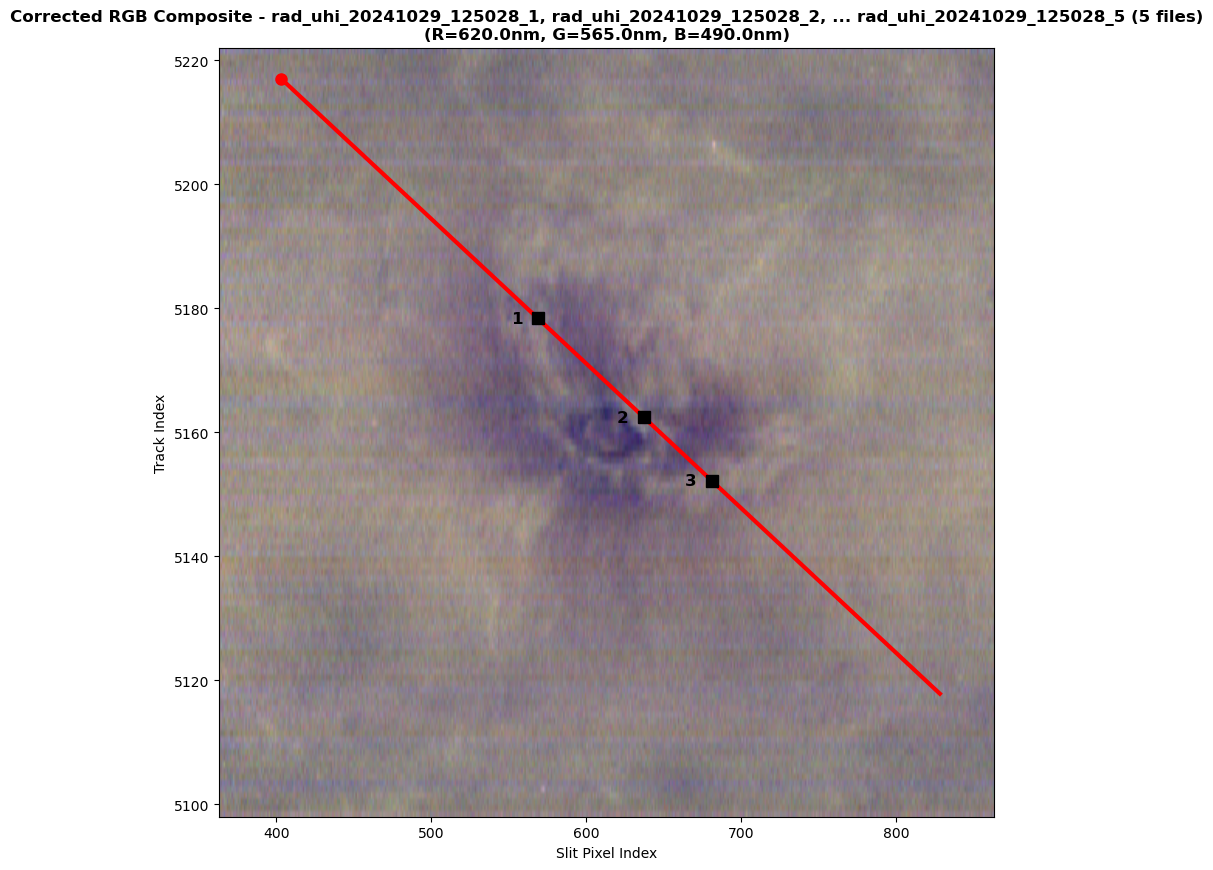

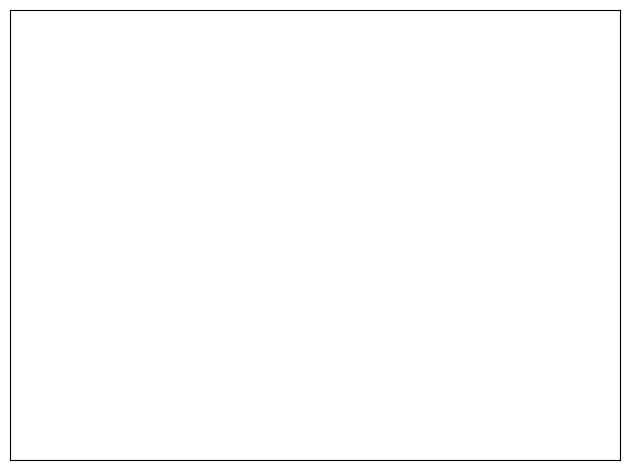


[2/5] Bomb 2
📊 Plotting RGB crop with line: Bomb 2
   Crop center: (track=1258, slit=250)
   Line (local): [(120, 120), (470, 25)]
   Feature markers at indices: [160, 195, 225]
✨ Manual per-channel normalization applied:
   Red:   [0.5300, 1.3500]
   Green: [0.5800, 1.3700]
   Blue:  [0.2000, 1.7300]
📐 Crop center: global track 1258 → local track 1258, slit 250
   Aspect ratio correction: 4.00:1 (track:slit)
   Slit pixels: 500, Track pixels: 124
🔍 Crop applied: track [1196:1320], slit [0:500]
   Resulting shape: (124, 500, 3)
📊 Extent: x=[0, 500], y=[1196, 1320]
📐 Image shape after transformations: (124, 500, 3)
🐛 DEBUG legend: has_overlays=False, roi_legend_loc=best, roi_overlay_mode=markers
   Line (display): (120.0, 1315.0) → (470.0, 1220.8)
   🔍 Line: (120.0,120.0)→(470.0,25.0), length=362.7, num_points=363
      Marker 0: index=160, t=0.4420 → (274.7,78.0)
      Marker 1: index=195, t=0.5387 → (308.5,68.8)
      Marker 2: index=225, t=0.6215 → (337.5,61.0)


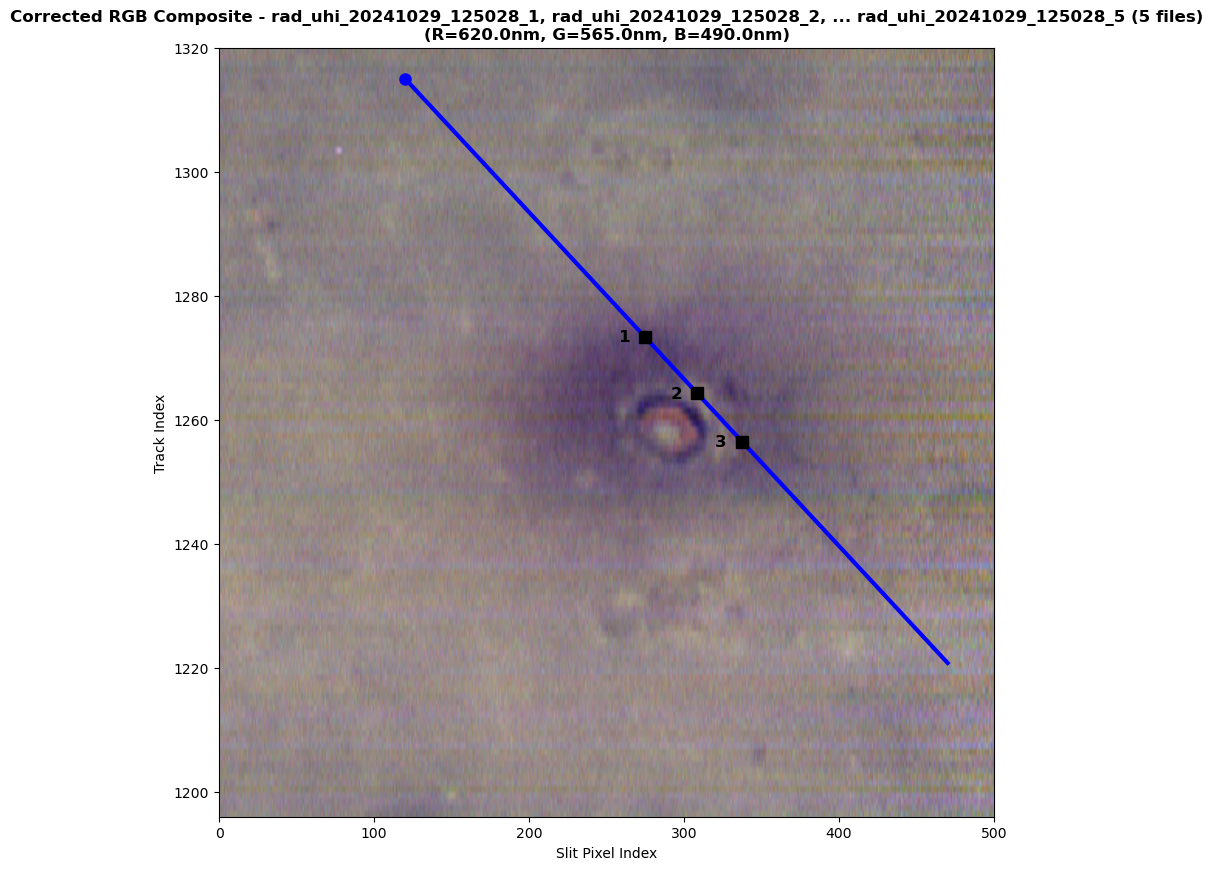

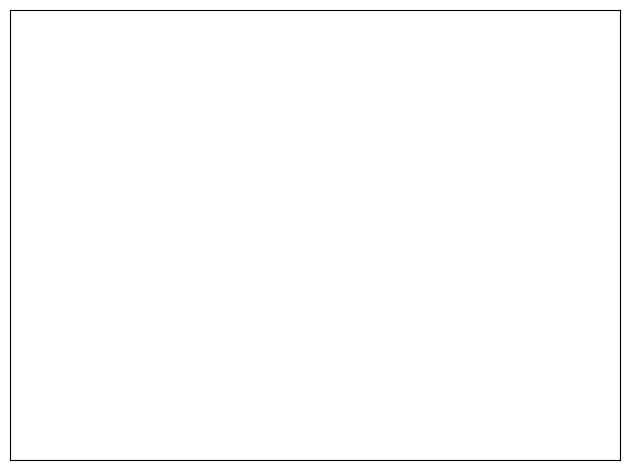


[3/5] Bomb 3
📊 Plotting RGB crop with line: Bomb 3
   Crop center: (track=5592, slit=700)
   Line (local): [(175, 110), (175, 20)]
   Feature markers at indices: [38, 47, 55]
✨ Manual per-channel normalization applied:
   Red:   [0.5300, 1.3500]
   Green: [0.5800, 1.3700]
   Blue:  [0.2000, 1.7300]
📐 Crop center: global track 5592 → local track 5592, slit 700
   Aspect ratio correction: 4.00:1 (track:slit)
   Slit pixels: 500, Track pixels: 124
🔍 Crop applied: track [5530:5654], slit [450:950]
   Resulting shape: (124, 500, 3)
📊 Extent: x=[450, 950], y=[5530, 5654]
📐 Image shape after transformations: (124, 500, 3)
🐛 DEBUG legend: has_overlays=False, roi_legend_loc=best, roi_overlay_mode=markers
   Line (display): (625.0, 5639.1) → (625.0, 5549.8)
   🔍 Line: (175.0,110.0)→(175.0,20.0), length=90.0, num_points=91
      Marker 0: index=38, t=0.4222 → (175.0,72.0)
      Marker 1: index=47, t=0.5222 → (175.0,63.0)
      Marker 2: index=55, t=0.6111 → (175.0,55.0)


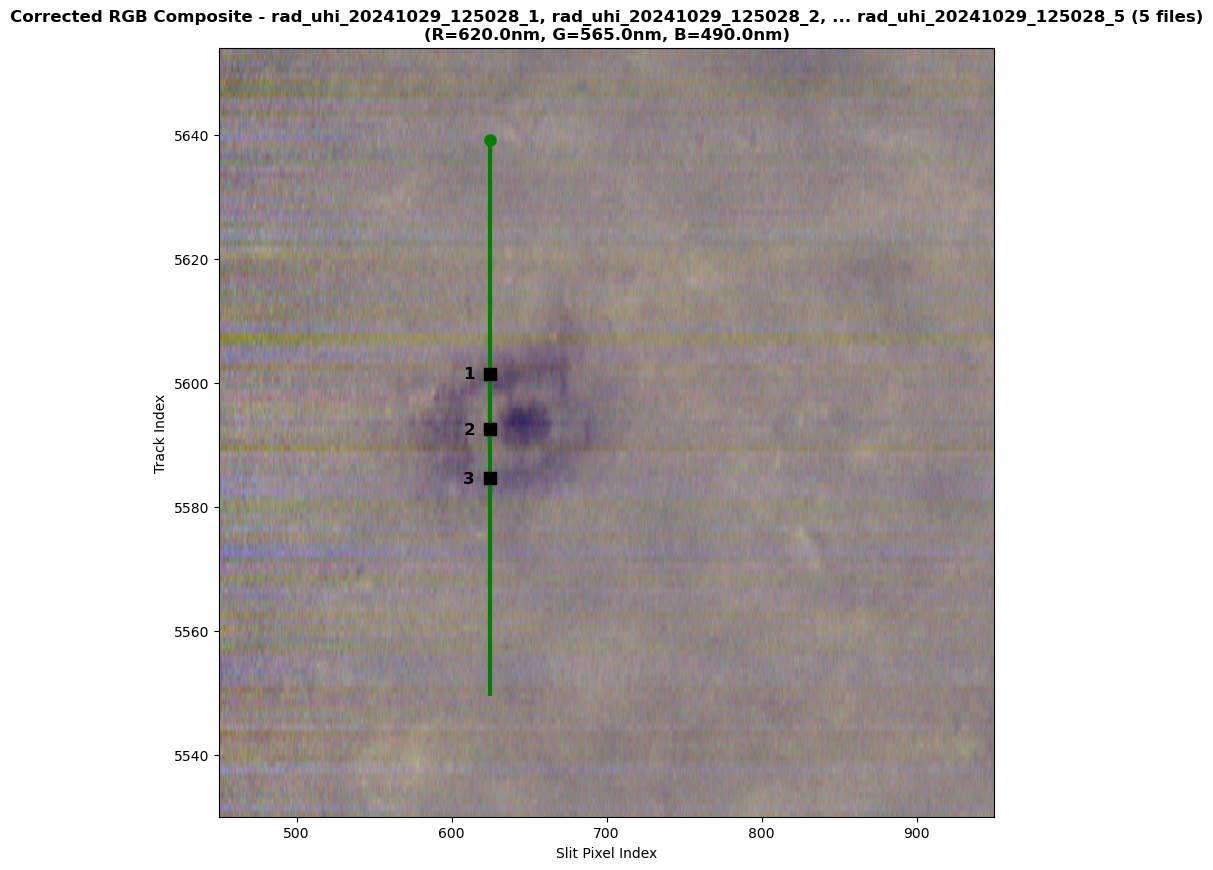

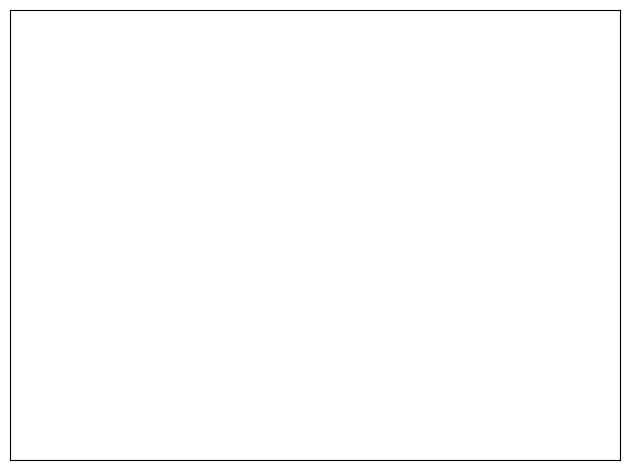


[4/5] Dark pits
📊 Plotting RGB crop with line: Dark pits
   Crop center: (track=717, slit=385)
   Line (local): [(15, 60), (435, 60)]
   Feature markers at indices: [115, 235, 335]
✨ Manual per-channel normalization applied:
   Red:   [0.5300, 1.3500]
   Green: [0.5800, 1.3700]
   Blue:  [0.2000, 1.7300]
📐 Crop center: global track 717 → local track 717, slit 385
   Aspect ratio correction: 4.00:1 (track:slit)
   Slit pixels: 500, Track pixels: 124
🔍 Crop applied: track [655:779], slit [135:635]
   Resulting shape: (124, 500, 3)
📊 Extent: x=[135, 635], y=[655, 779]
📐 Image shape after transformations: (124, 500, 3)
🐛 DEBUG legend: has_overlays=False, roi_legend_loc=best, roi_overlay_mode=markers
   Line (display): (150.0, 714.5) → (570.0, 714.5)
   🔍 Line: (15.0,60.0)→(435.0,60.0), length=420.0, num_points=421
      Marker 0: index=115, t=0.2738 → (130.0,60.0)
      Marker 1: index=235, t=0.5595 → (250.0,60.0)
      Marker 2: index=335, t=0.7976 → (350.0,60.0)


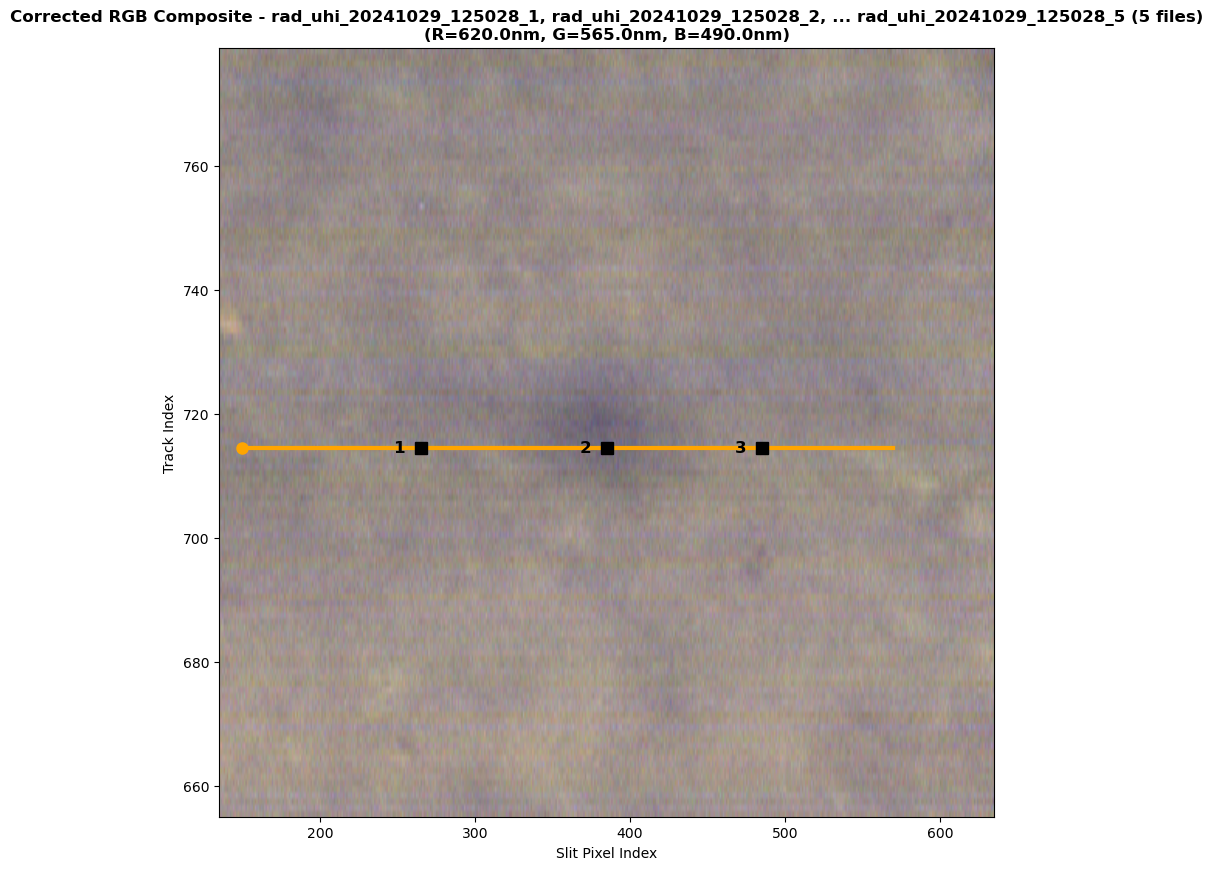

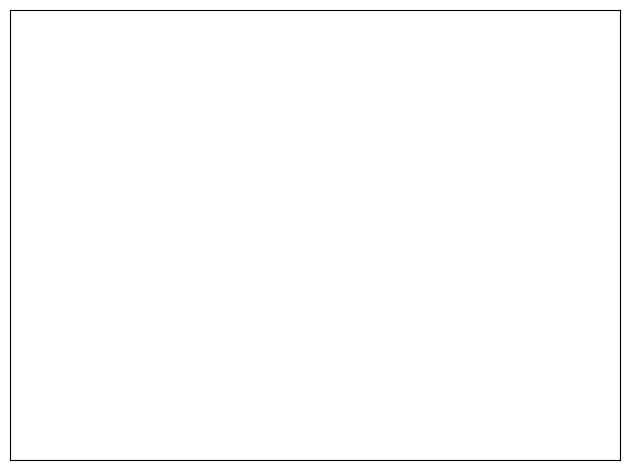


[5/5] Between 1-2
📊 Plotting RGB crop with line: Between 1-2
   Crop center: (track=4200, slit=482)
   Line (local): [(70, 60), (470, 60)]
✨ Manual per-channel normalization applied:
   Red:   [0.5300, 1.3500]
   Green: [0.5800, 1.3700]
   Blue:  [0.2000, 1.7300]
📐 Crop center: global track 4200 → local track 4200, slit 482
   Aspect ratio correction: 4.00:1 (track:slit)
   Slit pixels: 500, Track pixels: 124
🔍 Crop applied: track [4138:4262], slit [232:732]
   Resulting shape: (124, 500, 3)
📊 Extent: x=[232, 732], y=[4138, 4262]
📐 Image shape after transformations: (124, 500, 3)
🐛 DEBUG legend: has_overlays=False, roi_legend_loc=best, roi_overlay_mode=markers
   Line (display): (302.0, 4197.5) → (702.0, 4197.5)


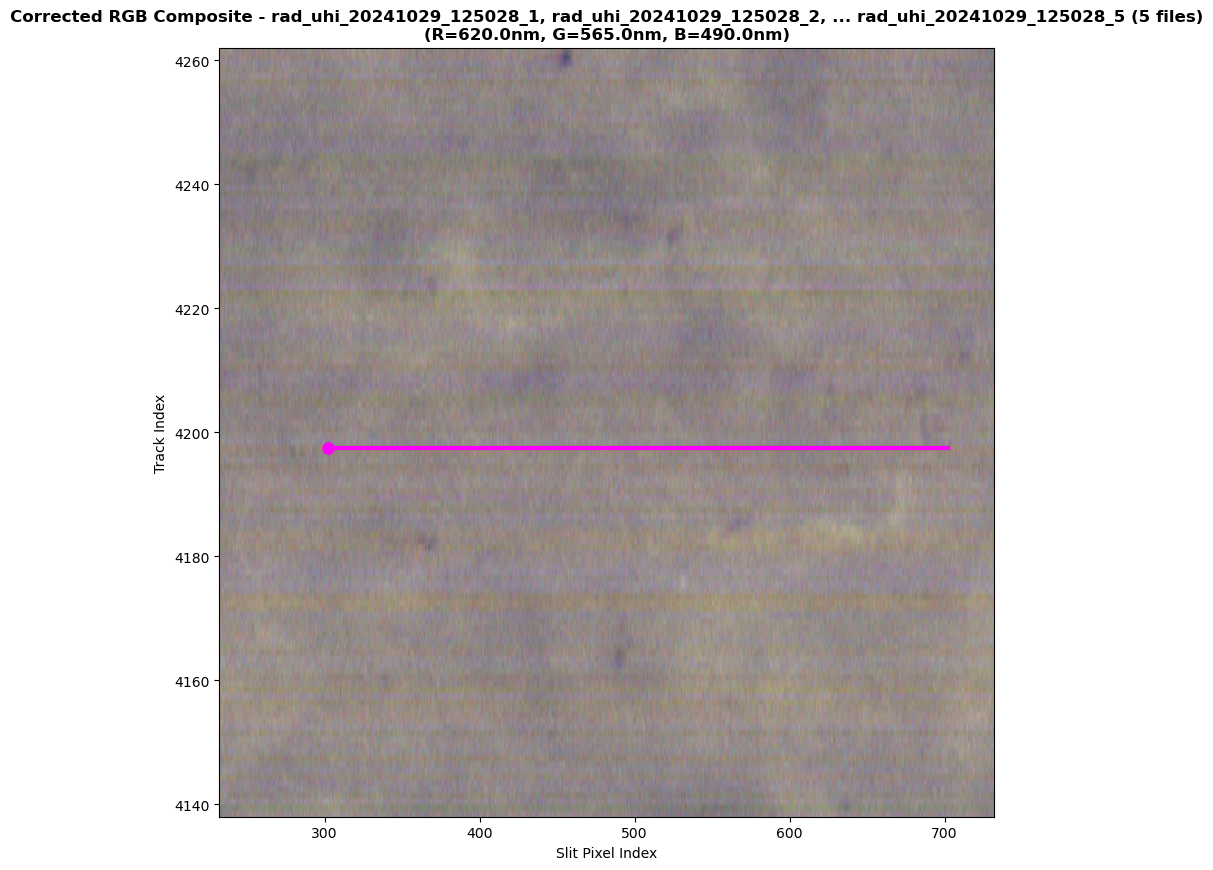

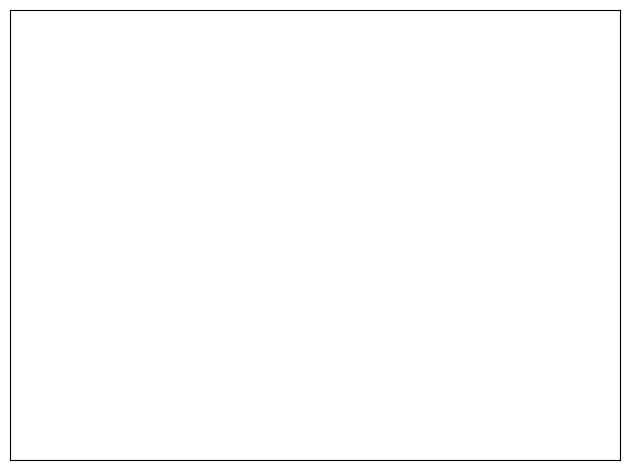


✅ Plotted all 5 RGB crops with lines!


In [11]:
# Loop through all crop regions and plot RGB crops with lines
print("=" * 80)
print("PLOTTING ALL RGB CROPS WITH LINES")
print("=" * 80)

# Feature markers with numbered labels for publication
feature_markers_028 = {
    "Bomb 1": {"indices": [170, 240, 285], "labels": ["1", "2", "3"]},
    "Bomb 2": {"indices": [160, 195, 225], "labels": ["1", "2", "3"]},
    "Bomb 3": {"indices": [38, 47, 55], "labels": ["1", "2", "3"]},
    "Dark pits": {"indices": [115, 235, 335], "labels": ["1", "2", "3"]},
    # "Between 1-2": {"indices": [150, 300], "labels": ["1", "2"]},
}

for i, region in enumerate(crop_regions_028):
    label = region["label"]
    line = crop_lines_028[label]
    color = line_colors_028[i]

    print(f"\n[{i+1}/{len(crop_regions_028)}] {label}")

    # Get feature markers for this line (if defined)
    features = feature_markers_028.get(label, {})

    # Plot RGB crop with line overlay (like notebook 14)
    fig = plot_crop_with_line(
        cube_028,
        crop_region=region,
        line_local=line,
        line_color=color,
        line_width=3,
        feature_indices=features.get("indices"),  # Add feature markers
        feature_labels=features.get("labels"),  # Add feature labels
        figsize=(10, 10),  # Square figure for publication
    )

    # Remove axis labels, ticks, and title for clean publication figure
    ax = plt.gca()
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_title("")
    ax.set_xticks([])
    ax.set_yticks([])
    plt.tight_layout()
    plt.show()

print(f"\n✅ Plotted all {len(crop_regions_028)} RGB crops with lines!")

In [12]:
# # Loop through all crop regions and plot RGB crops with lines
# print("=" * 80)
# print("PLOTTING ALL RGB CROPS WITH LINES")
# print("=" * 80)

# for i, region in enumerate(crop_regions_028):
#     label = region["label"]
#     line = crop_lines_028[label]
#     color = line_colors_028[i]

#     print(f"\n[{i+1}/{len(crop_regions_028)}] {label}")

#     # Plot RGB crop with line overlay (like notebook 14)
#     plot_crop_with_line(
#         cube_028,
#         crop_region=region,
#         line_local=line,
#         line_color=color,
#         line_width=3,
#     )

# print(f"\n✅ Plotted all {len(crop_regions_028)} RGB crops with lines!")

EXTRACTING INTENSITY PROFILES ALONG LINES (COMBINED PLOT)
[1/5] Bomb 1:
   Local:  [(40, 120), (465, 20)]
   Global: [(823, 5218), (398, 5118)]
   Length: 436.6 pixels
[2/5] Bomb 2:
   Local:  [(120, 120), (470, 25)]
   Global: [(380, 1316), (30, 1221)]
   Length: 362.7 pixels
[3/5] Bomb 3:
   Local:  [(175, 110), (175, 20)]
   Global: [(775, 5640), (775, 5550)]
   Length: 90.0 pixels
[4/5] Dark pits:
   Local:  [(15, 60), (435, 60)]
   Global: [(620, 715), (200, 715)]
   Length: 420.0 pixels
[5/5] Between 1-2:
   Local:  [(70, 60), (470, 60)]
   Global: [(662, 4198), (262, 4198)]
   Length: 400.0 pixels

📊 Plotting 5 intensity profiles...


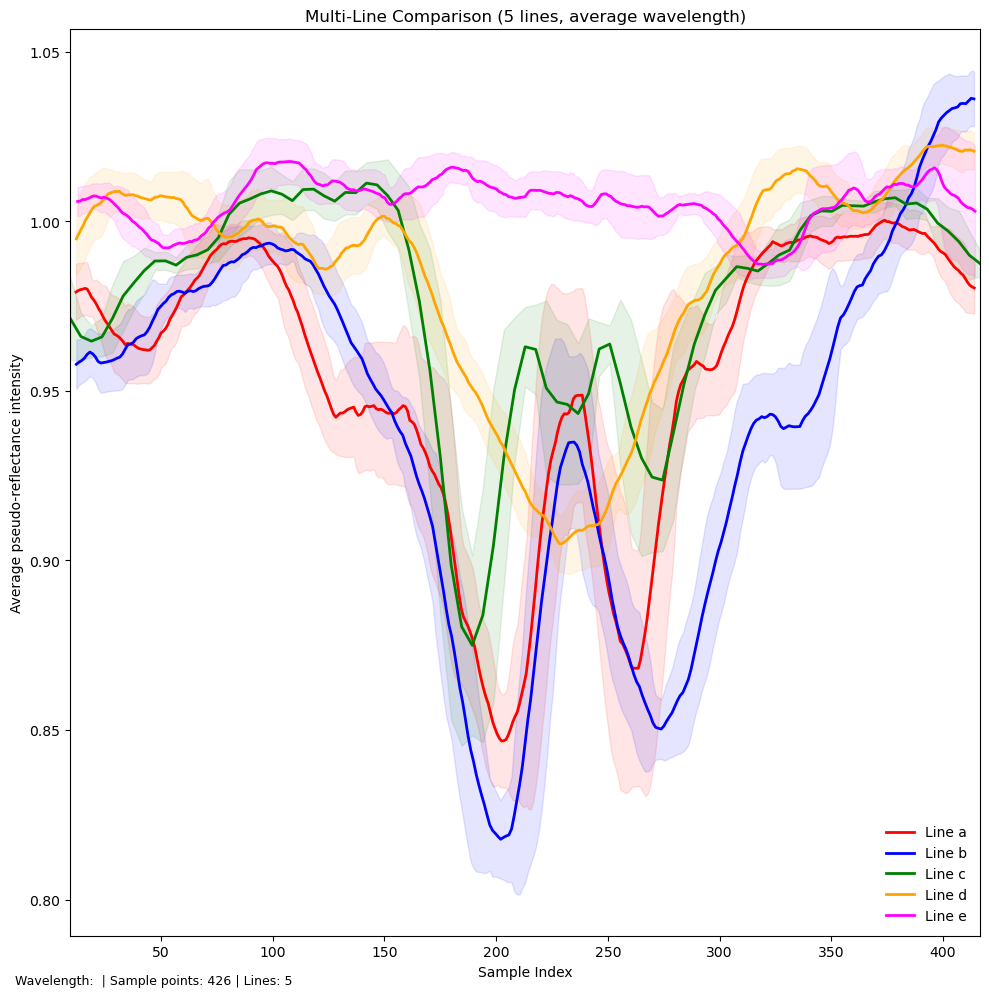


✅ Extracted intensity profiles!


In [13]:
# Extract intensity profiles for all crops - COMBINED IN ONE PLOT
# FIX: Account for flip_axes=True and flip_horizontal=True transformations
print("=" * 80)
print("EXTRACTING INTENSITY PROFILES ALONG LINES (COMBINED PLOT)")
print("=" * 80)

# Convert all local line coordinates to global coordinates
# CRITICAL: Must account for flip_axes=True and flip_horizontal=True used in plot_crop_with_line
all_lines_global = []
all_labels = []
all_colors = []

for i, region in enumerate(crop_regions_028):
    label = region["label"]
    line_local = crop_lines_028[label]
    color = line_colors_028[i]

    # Extract crop parameters
    track_center = region["track"]
    slit_center = region["slit"]
    crop_width = 500
    crop_aspect_ratio = 4
    crop_height = crop_width // crop_aspect_ratio

    # Calculate crop bounds in GLOBAL coordinates
    track_min = track_center - crop_height // 2
    slit_min = slit_center - crop_width // 2

    # Convert LOCAL line coordinates to GLOBAL coordinates
    # LOCAL coords are relative to the DISPLAYED image (after flip_axes and flip_horizontal)
    x1_local, y1_local = line_local[0]
    x2_local, y2_local = line_local[1]

    # CRITICAL COORDINATE TRANSFORMATION:
    # plot_crop_with_line uses flip_axes=True and flip_horizontal=True
    # flip_axes=True: swaps axes so horizontal=track, vertical=slit
    # flip_horizontal=True: mirrors horizontally (inverts x-axis)

    # After flip_axes=True:
    # - x (local horizontal, 0-500) corresponds to TRACK direction
    # - y (local vertical, 0-125) corresponds to SLIT direction

    # After flip_horizontal=True:
    # - x=0 on screen → track_max in data (right edge)
    # - x=crop_width on screen → track_min in data (left edge)
    # - So: track_global = track_max - x_local (inverted)

    # Map to global coordinates with transformations:
    # track1_global = track_center + crop_height // 2 - y1_local  # Invert y → track
    # slit1_global = slit_min + x1_local  # Direct mapping x → slit
    # track2_global = track_center + crop_height // 2 - y2_local
    # slit2_global = slit_min + x2_local

    # Map to global coordinates with transformations:
    # slit1_global = (
    #     slit_min + crop_width - x1_local
    # )  # Inverted x → slit (flip_horizontal)
    # track1_global = track_min + y1_local  # Direct y → track
    # slit2_global = slit_min + crop_width - x2_local
    # track2_global = track_min + y2_local

    # Map to global coordinates with transformations:
    # FIX: SWAP x1↔x2 and y1↔y2 to reverse line direction (match RGB display)
    # slit1_global = (
    #     slit_min + crop_width - x2_local
    # )  # SWAPPED: Use x2 for START (was x1)
    # track1_global = track_min + y2_local  # SWAPPED: Use y2 for START (was y1)
    # slit2_global = slit_min + crop_width - x1_local  # SWAPPED: Use x1 for END (was x2)
    # track2_global = track_min + y1_local  # SWAPPED: Use y1 for END (was y2)
    slit1_global = slit_min + crop_width - x1_local  # Inverted (flip_horizontal)
    track1_global = track_min + y1_local  # Direct
    slit2_global = slit_min + crop_width - x2_local
    track2_global = track_min + y2_local
    # Format: [(slit1, track1), (slit2, track2)] - matching plot_line_intensity_profile format
    line_global = [(slit1_global, track1_global), (slit2_global, track2_global)]

    # Calculate line length for diagnostic
    line_length = np.sqrt(
        (slit2_global - slit1_global) ** 2 + (track2_global - track1_global) ** 2
    )

    all_lines_global.append(line_global)
    all_labels.append(label)
    all_colors.append(color)

    print(f"[{i+1}/{len(crop_regions_028)}] {label}:")
    print(f"   Local:  {line_local}")
    print(f"   Global: {line_global}")
    print(f"   Length: {line_length:.1f} pixels")

# Rename labels to Line a-e
all_labels = ["Line a", "Line b", "Line c", "Line d", "Line e"][: len(all_labels)]

# Plot all intensity profiles in one figure
print(f"\n📊 Plotting {len(all_lines_global)} intensity profiles...")

# MONKEYPATCH: Prevent plt.show() from displaying until we customize legend
with patch.object(plt, "show", lambda: None):
    cube_028.plot_line_intensity_profile(
        perimeter_line=all_lines_global,
        use_average=True,
        moving_average_percent=6,
        show_markers=False,
        line_labels=all_labels,
        line_colors=all_colors,
        use_corrected=True,
        wavelength_range="all",
        figsize=(10, 10),  # Square figure for publication
        use_sparse_sampling=True,
        sparse_normalize_x=True,  # CRITICAL: Keep raw pixel indices for feature markers
    )

# Customize plot: remove grid, move legend to lower right, trim x-axis
ax = plt.gca()
ax.grid(False)

# Remove old legend and create new one in lower right (no border)
if ax.get_legend():
    ax.get_legend().remove()
handles, labels = ax.get_legend_handles_labels()
legend = ax.legend(
    handles,
    labels,
    loc="lower right",
    fontsize=10,
    frameon=False,  # No border/frame
    framealpha=1,
    facecolor="white",
)
legend.get_frame().set_alpha(1)
for lh in legend.legend_handles:
    lh.set_alpha(1)

# Trim x-axis to remove ALL whitespace by using actual data range
# Get the actual x-data from all plotted lines
all_lines = ax.get_lines()
if all_lines:
    min_x = min([min(line.get_xdata()) for line in all_lines])
    max_x = max([max(line.get_xdata()) for line in all_lines])
    ax.set_xlim(min_x, max_x)

plt.tight_layout()

# NOW show the plot with legend in lower right
plt.show()

print(f"\n✅ Extracted intensity profiles!")

WAVELENGTH COMPARISON WITH ADJUSTED MARKERS (ALL LINES)

[1/5] Bomb 1:
  Line length: 426 samples
  Moving average window: 25 samples (6%)
  Half window: 12 samples
  Offset used: 12 (AUTO)
  Original indices: [170, 240, 285]
  Adjusted indices: [158, 228, 273]
📊 Auto-calculated moving average window: 25 samples (6% of 426 samples)


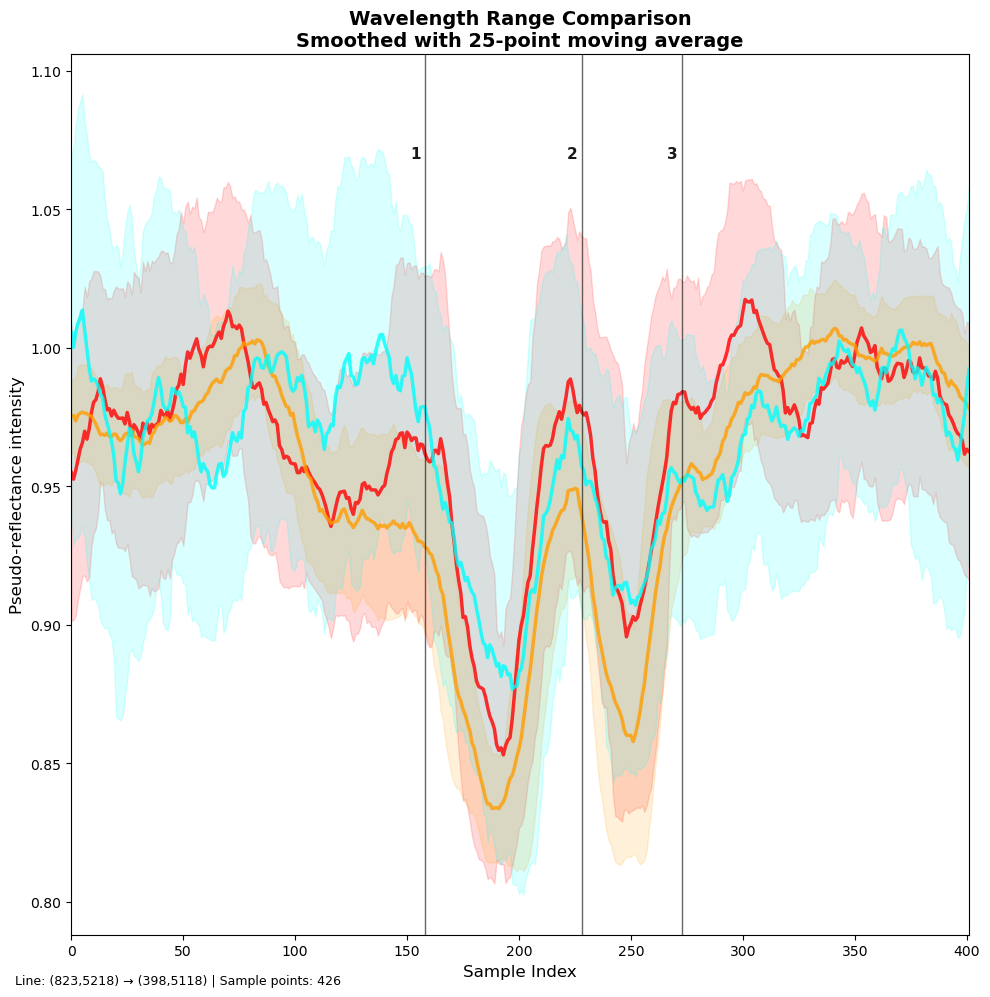


[2/5] Bomb 2:
  Line length: 351 samples
  Moving average window: 21 samples (6%)
  Half window: 10 samples
  Offset used: 10 (AUTO)
  Original indices: [160, 195, 225]
  Adjusted indices: [150, 185, 215]
📊 Auto-calculated moving average window: 21 samples (6% of 351 samples)


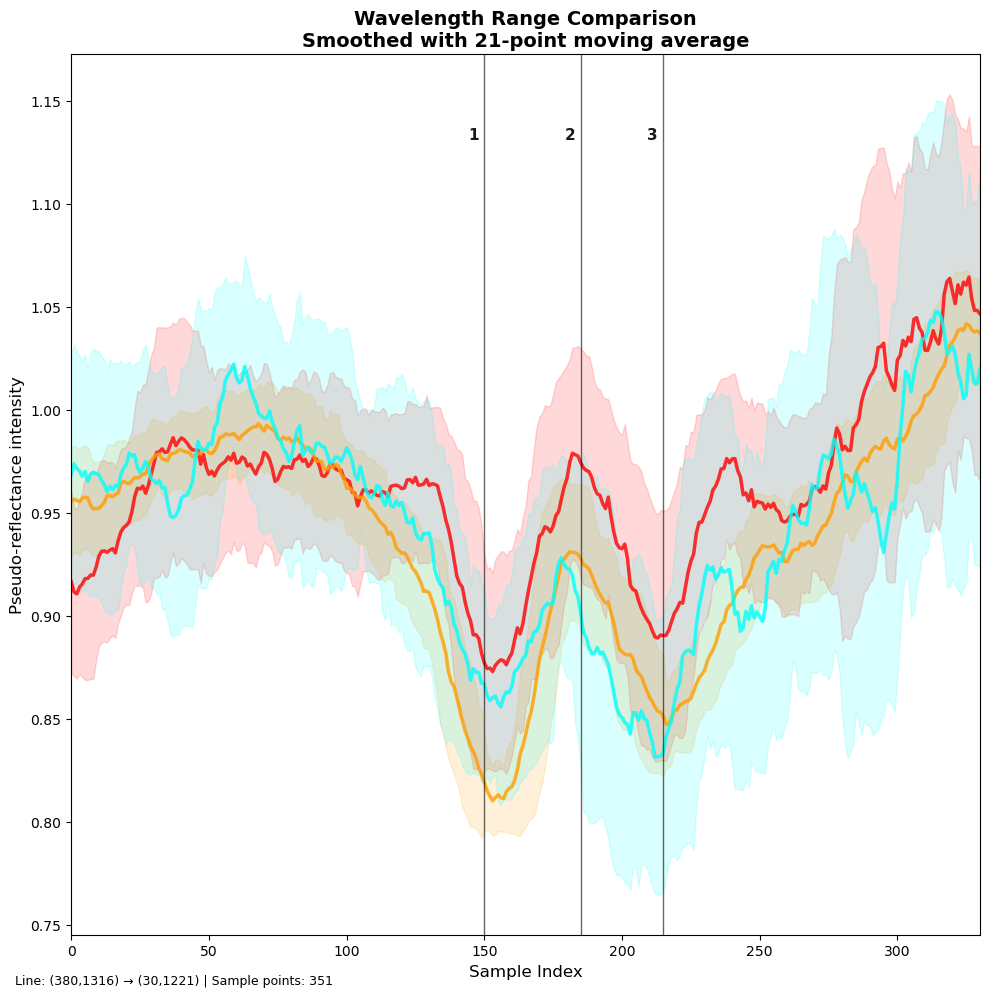


[3/5] Bomb 3:
  Line length: 91 samples
  Moving average window: 5 samples (6%)
  Half window: 2 samples
  Offset used: 2 (AUTO)
  Original indices: [38, 47, 55]
  Adjusted indices: [36, 45, 53]
📊 Auto-calculated moving average window: 5 samples (6% of 91 samples)


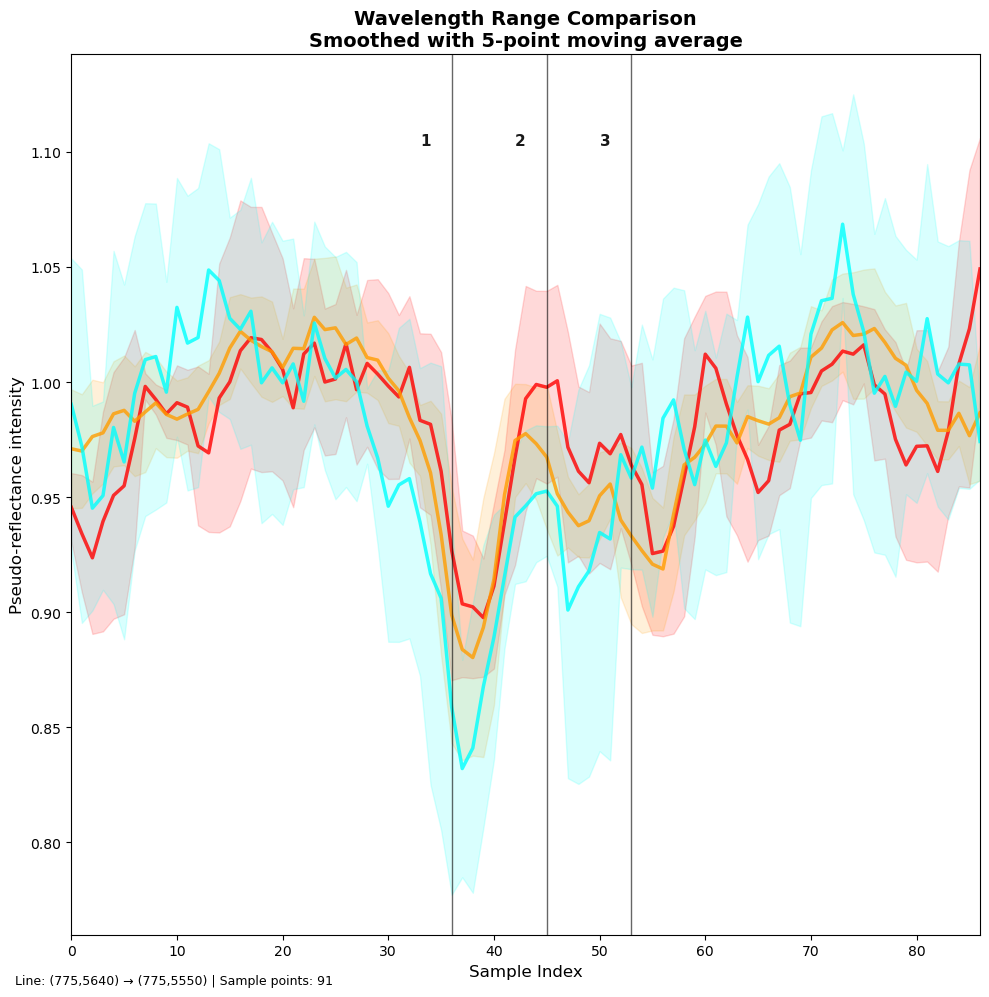


[4/5] Dark pits:
  Line length: 421 samples
  Moving average window: 25 samples (6%)
  Half window: 12 samples
  Offset used: 12 (AUTO)
  Original indices: [115, 235, 335]
  Adjusted indices: [103, 223, 323]
📊 Auto-calculated moving average window: 25 samples (6% of 421 samples)


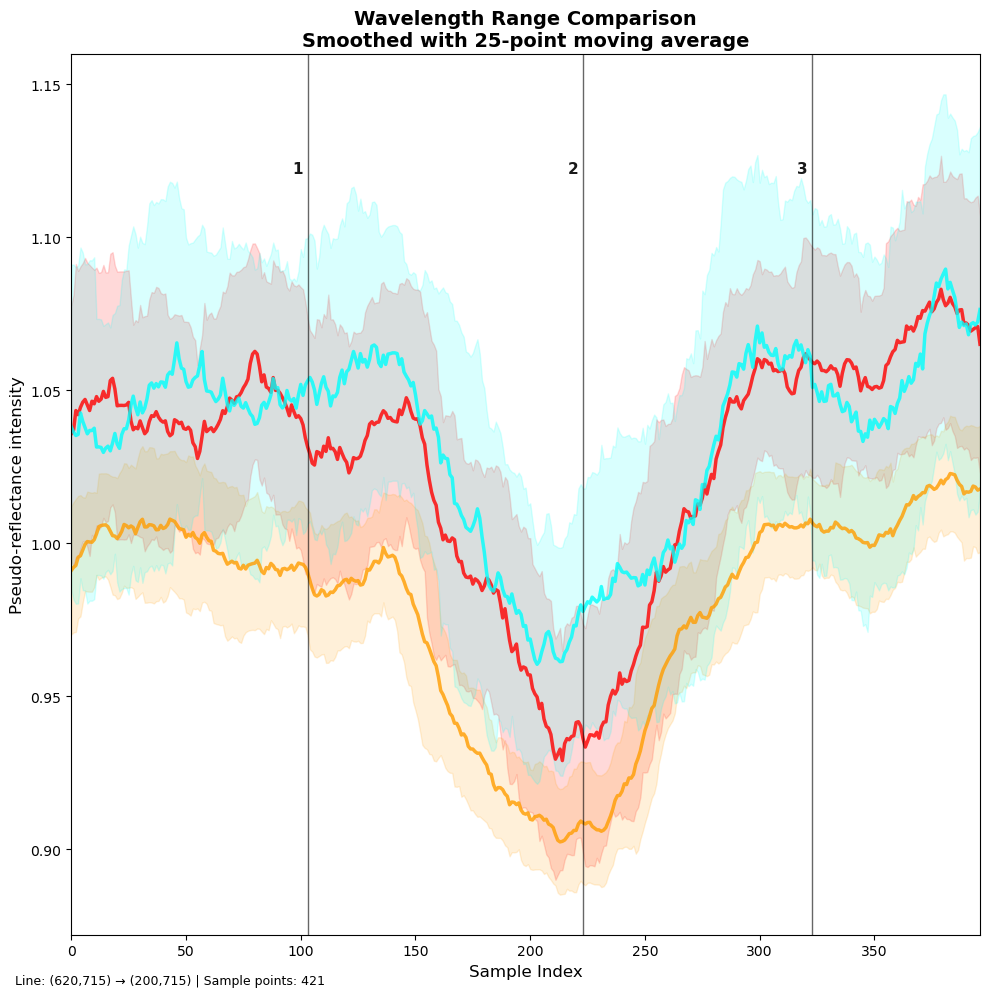


[5/5] Between 1-2:
  Line length: 401 samples
  Moving average window: 24 samples (6%)
  Half window: 12 samples
  Offset used: 12 (AUTO)
  Original indices: []
  Adjusted indices: []
📊 Auto-calculated moving average window: 24 samples (6% of 401 samples)


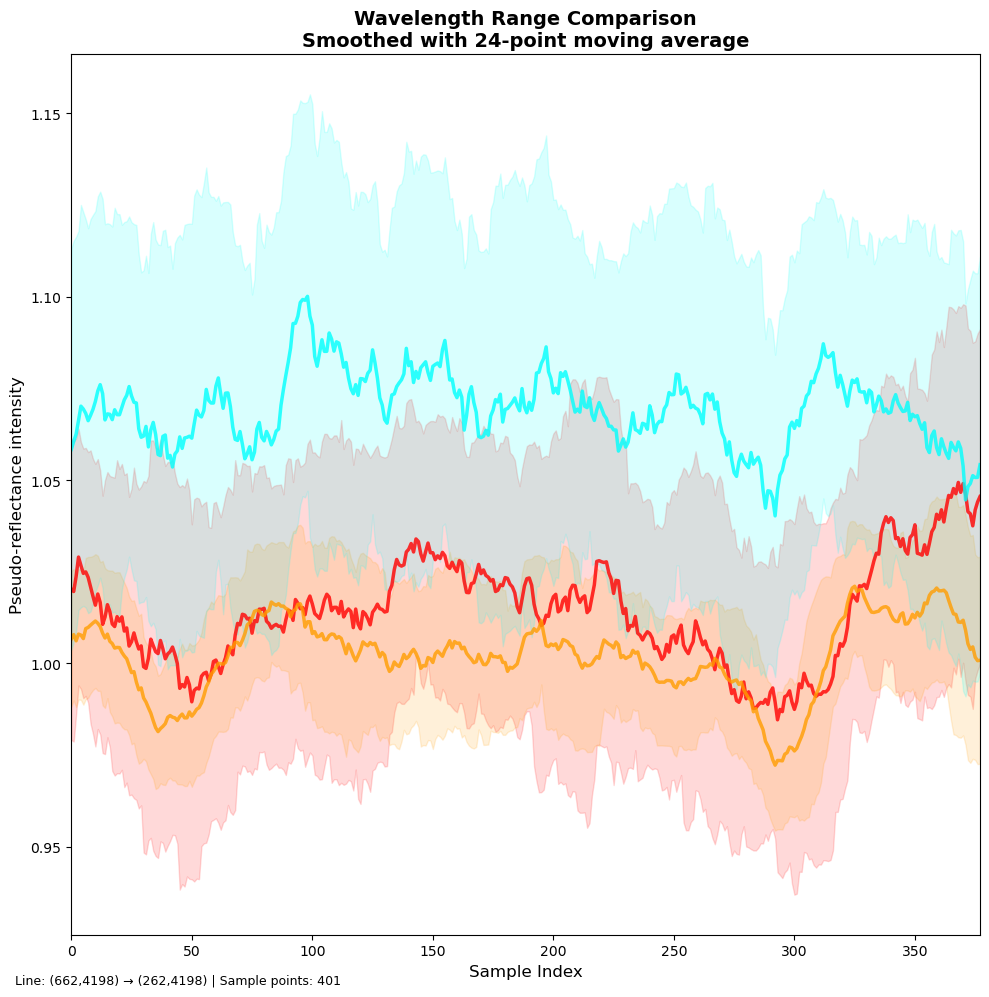


✅ All wavelength comparison plots complete!


In [14]:
# Wavelength comparison with CORRECTED marker indices (ALL 5 lines, manual offset option)
print("=" * 80)
print("WAVELENGTH COMPARISON WITH ADJUSTED MARKERS (ALL LINES)")
print("=" * 80)

wavelengths = [677, 610, 490]  # Red, orange, cyan
moving_average_percent = 6

# Manual offset per line (None = auto-calculate from moving average %)
manual_offsets = {
    "Bomb 1": None,  # None = use half_window (auto)
    # "Bomb 1": 60,  # None = use half_window (auto)
    "Bomb 2": None,  # Or set integer like: 20
    "Bomb 3": None,
    "Dark pits": None,
    "Between 1-2": None,
}

for i, region in enumerate(crop_regions_028):
    label = region["label"]
    line_local = crop_lines_028[label]

    # Extract crop parameters
    track_center = region["track"]
    slit_center = region["slit"]
    crop_width = 500
    crop_aspect_ratio = 4
    crop_height = crop_width // crop_aspect_ratio

    # Calculate crop bounds in GLOBAL coordinates
    track_min = track_center - crop_height // 2
    slit_min = slit_center - crop_width // 2

    # Convert LOCAL line coordinates to GLOBAL coordinates
    x1_local, y1_local = line_local[0]
    x2_local, y2_local = line_local[1]

    # After transformations: x=slit (inverted), y=track (direct)
    slit1_global = slit_min + crop_width - x1_local  # Inverted (flip_horizontal)
    track1_global = track_min + y1_local  # Direct
    slit2_global = slit_min + crop_width - x2_local
    track2_global = track_min + y2_local

    line_global = [(slit1_global, track1_global), (slit2_global, track2_global)]

    # Calculate line length and moving average offset
    line_length = max(abs(x2_local - x1_local), abs(y2_local - y1_local)) + 1
    moving_average_window = max(1, int(line_length * moving_average_percent / 100))
    half_window = moving_average_window // 2

    # Use manual offset if provided, otherwise auto-calculate
    manual_offset = manual_offsets.get(label, None)
    offset = manual_offset if manual_offset is not None else half_window

    print(f"\n[{i+1}/{len(crop_regions_028)}] {label}:")
    print(f"  Line length: {line_length} samples")
    print(
        f"  Moving average window: {moving_average_window} samples ({moving_average_percent}%)"
    )
    print(f"  Half window: {half_window} samples")
    print(
        f"  Offset used: {offset} {'(MANUAL)' if manual_offset is not None else '(AUTO)'}"
    )

    # Get original feature markers
    features = feature_markers_028.get(label, {})
    original_indices = features.get("indices", [])
    original_labels = features.get("labels", [])

    # Adjust indices by subtracting offset
    adjusted_indices = [idx - offset for idx in original_indices]

    print(f"  Original indices: {original_indices}")
    print(f"  Adjusted indices: {adjusted_indices}")

    # MONKEYPATCH: Prevent plt.show() from displaying until we add markers
    with patch.object(plt, "show", lambda: None):
        cube_028.plot_wavelength_comparison(
            line=line_global,
            wavelength_ranges=wavelengths,
            moving_average_percent=moving_average_percent,
            use_corrected=True,
            figsize=(10, 10),
        )

    # Add markers with ADJUSTED indices
    add_feature_markers_to_plot(
        feature_indices=adjusted_indices,
        feature_labels=original_labels,
    )

    # Remove legend completely and grid, then trim x-axis
    ax = plt.gca()
    ax.grid(False)
    ax.set_axisbelow(False)
    if ax.get_legend():
        ax.get_legend().remove()

    # Trim x-axis to remove ALL whitespace by using actual data range
    # Get the actual x-data from all plotted lines
    all_lines = ax.get_lines()
    if all_lines:
        min_x = min([min(line.get_xdata()) for line in all_lines])
        max_x = max([max(line.get_xdata()) for line in all_lines])
        ax.set_xlim(min_x, max_x)

    plt.tight_layout()

    plt.show()

print(f"\n✅ All wavelength comparison plots complete!")

In [15]:
# Save ONE test PDF to verify rasterization
import matplotlib.pyplot as plt
from unittest.mock import patch
from pathlib import Path

print("Saving test PDF...")

# Create test folder
test_dir = Path.cwd().parent / "images_for_publication" / "TEST_028"
test_dir.mkdir(parents=True, exist_ok=True)

# Test with first crop
region = crop_regions_028[0]
line = crop_lines_028[region["label"]]
features = feature_markers_028.get(region["label"], {})

# Create plot
with patch.object(plt, "show", lambda: None):
    fig = plot_crop_with_line(
        cube_028,
        crop_region=region,
        line_local=line,
        line_color=line_colors_028[0],
        line_width=3,
        feature_indices=features.get("indices"),
        feature_labels=features.get("labels"),
        figsize=(10, 10),
    )

    # Remove axes
    ax = plt.gca()
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_title("")
    ax.set_xticks([])
    ax.set_yticks([])
    plt.tight_layout()

# Save PDF
test_file = test_dir / "test_bomb1.pdf"
plt.savefig(test_file, format="pdf", bbox_inches="tight", dpi=300)
plt.close()

# Check file size
file_size_kb = test_file.stat().st_size / 1024
print(f"\n✅ Saved: {test_file}")
print(f"📏 File size: {file_size_kb:.1f} KB")
print(f"\n💡 Expected:")
print(f"   - Raster (good): 100-500 KB")
print(f"   - Vector (bad): <50 KB or >2 MB")

Saving test PDF...
📊 Plotting RGB crop with line: Bomb 1
   Crop center: (track=5160, slit=613)
   Line (local): [(40, 120), (465, 20)]
   Feature markers at indices: [170, 240, 285]
✨ Manual per-channel normalization applied:
   Red:   [0.5300, 1.3500]
   Green: [0.5800, 1.3700]
   Blue:  [0.2000, 1.7300]
📐 Crop center: global track 5160 → local track 5160, slit 613
   Aspect ratio correction: 4.00:1 (track:slit)
   Slit pixels: 500, Track pixels: 124
🔍 Crop applied: track [5098:5222], slit [363:863]
   Resulting shape: (124, 500, 3)
📊 Extent: x=[363, 863], y=[5098, 5222]
📐 Image shape after transformations: (124, 500, 3)
🐛 DEBUG legend: has_overlays=False, roi_legend_loc=best, roi_overlay_mode=markers
   Line (display): (403.0, 5217.0) → (828.0, 5117.8)
   🔍 Line: (40.0,120.0)→(465.0,20.0), length=436.6, num_points=437
      Marker 0: index=170, t=0.3899 → (205.7,81.0)
      Marker 1: index=240, t=0.5505 → (273.9,65.0)
      Marker 2: index=285, t=0.6537 → (317.8,54.6)

✅ Saved: e:\m

In [ ]:
# TEST: Compare different save formats
import matplotlib.pyplot as plt
from unittest.mock import patch
from pathlib import Path

print("Testing different save formats...")

test_dir = Path.cwd().parent / "images_for_publication" / "TEST_028"
test_dir.mkdir(parents=True, exist_ok=True)

# Get crop data
region = crop_regions_028[0]
line = crop_lines_028[region["label"]]
features = feature_markers_028.get(region["label"], {})

# Create plot
with patch.object(plt, "show", lambda: None):
    fig = plot_crop_with_line(
        cube_028,
        crop_region=region,
        line_local=line,
        line_color=line_colors_028[0],
        line_width=3,
        feature_indices=features.get("indices"),
        feature_labels=features.get("labels"),
        figsize=(10, 10),
    )

    ax = plt.gca()
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_title("")
    ax.set_xticks([])
    ax.set_yticks([])
    plt.tight_layout()

# Save in different formats
formats = [
    ("test_format.pdf", "pdf"),
    ("test_format.png", "png"),
    ("test_format.tiff", "tiff"),
    ("test_format.svg", "svg"),
]

print("\nSaving to different formats:")
for filename, fmt in formats:
    filepath = test_dir / filename
    plt.savefig(filepath, format=fmt, bbox_inches="tight", dpi=300)
    size_kb = filepath.stat().st_size / 1024
    print(f"  {filename}: {size_kb:.1f} KB")

plt.close()
print(f"\n✅ Files saved to: {test_dir}")
print("\nCompare these files to see which format preserves quality!")

## ⚠️ RESTART KERNEL REQUIRED

**The matplotlib backend configuration has been removed from the import cell above.**

To see the fix in action:
1. **Restart kernel** (clear all variables)
2. Re-run transect 028 import cell (cell 68)
3. Re-run subsequent cells to load data and display images

The RGB cropped images should now display as high-quality raster images in the notebook (same as notebook 14).


# 📄 Export Publication-Ready PDFs

Save all transect 028 plots as high-quality PDFs for Adobe Illustrator editing.

In [16]:
# Create output folder structure for transect 028
from pathlib import Path

output_dir = (
    Path.cwd().parent / "images_for_publication" / "intensity_profiles" / "transect_028"
)
output_dir.mkdir(parents=True, exist_ok=True)

print(f"✅ Output folder created: {output_dir}")

✅ Output folder created: e:\mjosa_complete\gref4hsi\mjosa_code\images_for_publication\intensity_profiles\transect_028


In [17]:
# Save RGB crop plots as PDFs
import matplotlib.pyplot as plt
from unittest.mock import patch

print("=" * 80)
print("SAVING RGB CROPS AS PDFs")
print("=" * 80)

for i, region in enumerate(crop_regions_028):
    label = region["label"]
    line = crop_lines_028[label]
    color = line_colors_028[i]

    # Get feature markers for this line
    features = feature_markers_028.get(label, {})

    # Create plot (without showing)
    with patch.object(plt, "show", lambda: None):
        fig = plot_crop_with_line(
            cube_028,
            crop_region=region,
            line_local=line,
            line_color=color,
            line_width=3,
            feature_indices=features.get("indices"),
            feature_labels=features.get("labels"),
            figsize=(10, 10),
        )

        # Remove axis elements
        ax = plt.gca()
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.set_title("")
        ax.set_xticks([])
        ax.set_yticks([])
        plt.tight_layout()

    # Save as PDF
    filename = f"rgb_crop_{label.lower().replace(' ', '_')}.pdf"
    filepath = output_dir / filename
    plt.savefig(filepath, format="pdf", bbox_inches="tight", dpi=600)
    plt.close()

    print(f"  [{i+1}/{len(crop_regions_028)}] Saved: {filename}")

print(f"\n✅ Saved {len(crop_regions_028)} RGB crop PDFs!")

SAVING RGB CROPS AS PDFs
📊 Plotting RGB crop with line: Bomb 1
   Crop center: (track=5160, slit=613)
   Line (local): [(40, 120), (465, 20)]
   Feature markers at indices: [170, 240, 285]
✨ Manual per-channel normalization applied:
   Red:   [0.5300, 1.3500]
   Green: [0.5800, 1.3700]
   Blue:  [0.2000, 1.7300]
📐 Crop center: global track 5160 → local track 5160, slit 613
   Aspect ratio correction: 4.00:1 (track:slit)
   Slit pixels: 500, Track pixels: 124
🔍 Crop applied: track [5098:5222], slit [363:863]
   Resulting shape: (124, 500, 3)
📊 Extent: x=[363, 863], y=[5098, 5222]
📐 Image shape after transformations: (124, 500, 3)
🐛 DEBUG legend: has_overlays=False, roi_legend_loc=best, roi_overlay_mode=markers
   Line (display): (403.0, 5217.0) → (828.0, 5117.8)
   🔍 Line: (40.0,120.0)→(465.0,20.0), length=436.6, num_points=437
      Marker 0: index=170, t=0.3899 → (205.7,81.0)
      Marker 1: index=240, t=0.5505 → (273.9,65.0)
      Marker 2: index=285, t=0.6537 → (317.8,54.6)
  [1/5] 

In [18]:
# Save combined intensity profile as PDF
import matplotlib.pyplot as plt

print("=" * 80)
print("SAVING COMBINED INTENSITY PROFILE AS PDF")
print("=" * 80)

# Recreate the combined intensity profile plot (prevent internal show)
with patch.object(plt, "show", lambda: None):
    cube_028.plot_line_intensity_profile(
        perimeter_line=all_lines_global,
        use_average=True,
        moving_average_percent=6,
        show_markers=False,
        line_labels=["Line a", "Line b", "Line c", "Line d", "Line e"][
            : len(all_lines_global)
        ],
        line_colors=all_colors,
        use_corrected=True,
        wavelength_range="all",
        figsize=(10, 10),
        use_sparse_sampling=True,
        sparse_normalize_x=True,
    )

# Move legend to lower right with fully solid background (no border) and remove grid
ax = plt.gca()
ax.grid(False)

# Remove old legend and create new one in lower right (no border)
if ax.get_legend():
    ax.get_legend().remove()
handles, labels = ax.get_legend_handles_labels()
legend = ax.legend(
    handles,
    labels,
    loc="lower right",
    fontsize=10,
    frameon=False,  # No border/frame
    framealpha=1,
    facecolor="white",
)
legend.get_frame().set_alpha(1)
for lh in legend.legend_handles:
    lh.set_alpha(1)

# Trim x-axis to remove ALL whitespace by using actual data range
all_lines = ax.get_lines()
if all_lines:
    min_x = min([min(line.get_xdata()) for line in all_lines])
    max_x = max([max(line.get_xdata()) for line in all_lines])
    ax.set_xlim(min_x, max_x)

plt.tight_layout()

# Save as PDF
filepath = output_dir / "combined_intensity_profiles.pdf"
plt.savefig(filepath, format="pdf", bbox_inches="tight", dpi=300)
plt.close()

print(f"✅ Saved: combined_intensity_profiles.pdf")

SAVING COMBINED INTENSITY PROFILE AS PDF
✅ Saved: combined_intensity_profiles.pdf


In [19]:
# Save wavelength comparison plots as PDFs
import matplotlib.pyplot as plt
from unittest.mock import patch

print("=" * 80)
print("SAVING WAVELENGTH COMPARISON PLOTS AS PDFs")
print("=" * 80)

wavelengths = [677, 610, 490]
moving_average_percent = 6

for i, region in enumerate(crop_regions_028):
    label = region["label"]
    line_local = crop_lines_028[label]

    # Extract crop parameters and convert to global coordinates
    track_center = region["track"]
    slit_center = region["slit"]
    crop_width = 500
    crop_aspect_ratio = 4
    crop_height = crop_width // crop_aspect_ratio
    track_min = track_center - crop_height // 2
    slit_min = slit_center - crop_width // 2

    x1_local, y1_local = line_local[0]
    x2_local, y2_local = line_local[1]

    slit1_global = slit_min + crop_width - x1_local
    track1_global = track_min + y1_local
    slit2_global = slit_min + crop_width - x2_local
    track2_global = track_min + y2_local

    line_global = [(slit1_global, track1_global), (slit2_global, track2_global)]

    # Calculate offset for markers
    line_length = max(abs(x2_local - x1_local), abs(y2_local - y1_local)) + 1
    moving_average_window = max(1, int(line_length * moving_average_percent / 100))
    half_window = moving_average_window // 2

    # Get feature markers and adjust indices
    features = feature_markers_028.get(label, {})
    original_indices = features.get("indices", [])
    original_labels = features.get("labels", [])
    adjusted_indices = [idx - half_window for idx in original_indices]

    # Create plot (without showing)
    with patch.object(plt, "show", lambda: None):
        cube_028.plot_wavelength_comparison(
            line=line_global,
            wavelength_ranges=wavelengths,
            moving_average_percent=moving_average_percent,
            use_corrected=True,
            figsize=(10, 10),
        )

        # Add markers
        add_feature_markers_to_plot(
            feature_indices=adjusted_indices,
            feature_labels=original_labels,
        )

        # Remove legend completely and grid, then trim x-axis
        ax = plt.gca()
        ax.grid(False)
        ax.set_axisbelow(False)
        if ax.get_legend():
            ax.get_legend().remove()

        # Trim x-axis to remove ALL whitespace by using actual data range
        all_lines = ax.get_lines()
        if all_lines:
            min_x = min([min(line.get_xdata()) for line in all_lines])
            max_x = max([max(line.get_xdata()) for line in all_lines])
            ax.set_xlim(min_x, max_x)

        plt.tight_layout()

    # Save as PDF
    filename = f"wavelength_comparison_{label.lower().replace(' ', '_')}.pdf"
    filepath = output_dir / filename
    plt.savefig(filepath, format="pdf", bbox_inches="tight", dpi=300)
    plt.close()

    print(f"  [{i+1}/{len(crop_regions_028)}] Saved: {filename}")

print(f"\n✅ Saved {len(crop_regions_028)} wavelength comparison PDFs!")

SAVING WAVELENGTH COMPARISON PLOTS AS PDFs
📊 Auto-calculated moving average window: 25 samples (6% of 426 samples)
  [1/5] Saved: wavelength_comparison_bomb_1.pdf
📊 Auto-calculated moving average window: 21 samples (6% of 351 samples)
  [2/5] Saved: wavelength_comparison_bomb_2.pdf
📊 Auto-calculated moving average window: 5 samples (6% of 91 samples)
  [3/5] Saved: wavelength_comparison_bomb_3.pdf
📊 Auto-calculated moving average window: 25 samples (6% of 421 samples)
  [4/5] Saved: wavelength_comparison_dark_pits.pdf
📊 Auto-calculated moving average window: 24 samples (6% of 401 samples)
  [5/5] Saved: wavelength_comparison_between_1-2.pdf

✅ Saved 5 wavelength comparison PDFs!
